# Project Title : **Digital Signals**


Overview: this project is about detecting mental health issues using ML & Dp models and we will build it following Crisp_DM methodology

AT the end of this project we aims to have as OUTPUTS:


* Predicted class(low/moderate/high) Risk



* Probability score per class




Note !!! :

this project is:

  (-):
      
  *   NOT a diagnostic tool
  *   NOT medical advice
  *   NOT a replacement for professional care


  (+):

  *   Risk classification for awareness & early intervention


# Step : **Data Understanding**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import re
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report 
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV


from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE


from copy import deepcopy


import warnings
warnings.filterwarnings('ignore')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df1=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/raw/df1.csv")
df2=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/raw/df2.csv")
df3=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/raw/df3.csv")
df4=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/raw/df4.csv")
df5=pd.read_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/raw/df5.csv")

In [3]:
print("df1 dataset")
print(df1.head())
print("\n****************************")

print("df2 dataset")
print(df2.head())
print("\n****************************")

print("df3 dataset")
print(df3.head())
print("\n****************************")

print("df4 dataset")
print(df4.head())
print("\n****************************")

print("df5 dataset")
print(df5.head())


df1 dataset
   Unnamed: 0                                          statement      status
0       22261  Just as the the title says. I feel like one is...  Depression
1       41400  a blackened sky encroached tugging behind it m...  Depression
2       20065  It gives you insomnia, which in turn makes you...  Depression
3       30036  Hello all, I'm a new submitter to this channel...      Normal
4         780                   Thank God the CB is over for Eid      Normal

****************************
df2 dataset
   Unnamed: 0                                               text        class
0      111734  I Don't know?7? Months self harm free and the ...      suicide
1      224358  I HAVE TO START BECOMING RICH I HAVE TO START ...  non-suicide
2       18790  A poem (haiku) for u/Me-Game-Dev hi, hello hel...  non-suicide
3       21196  I've honestly got no idea what to do anymore.I...      suicide
4       46089  Do you ever just cry? Like you just think abou...  non-suicide

***************

In [4]:
datasets = [df1, df2, df3, df4, df5]

for i, df in enumerate(datasets, start=1):
    print(f"\n{'*'*40}")
    print(f"Dataset df{i}")
    print("Shape:", df.shape)
    print(f"df{i} Columns:\n{df.columns}")
    print(f"df{i} Dataset:\n{df.info()}")
    print("\nNull values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())



****************************************
Dataset df1
Shape: (7517, 3)
df1 Columns:
Index(['Unnamed: 0', 'statement', 'status'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7517 entries, 0 to 7516
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  7517 non-null   int64 
 1   statement   7452 non-null   object
 2   status      7517 non-null   object
dtypes: int64(1), object(2)
memory usage: 176.3+ KB
df1 Dataset:
None

Null values:
 Unnamed: 0     0
statement     65
status         0
dtype: int64

Duplicate rows: 0

****************************************
Dataset df2
Shape: (1487, 3)
df2 Columns:
Index(['Unnamed: 0', 'text', 'class'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1487 non-null   int64 
 1   text       

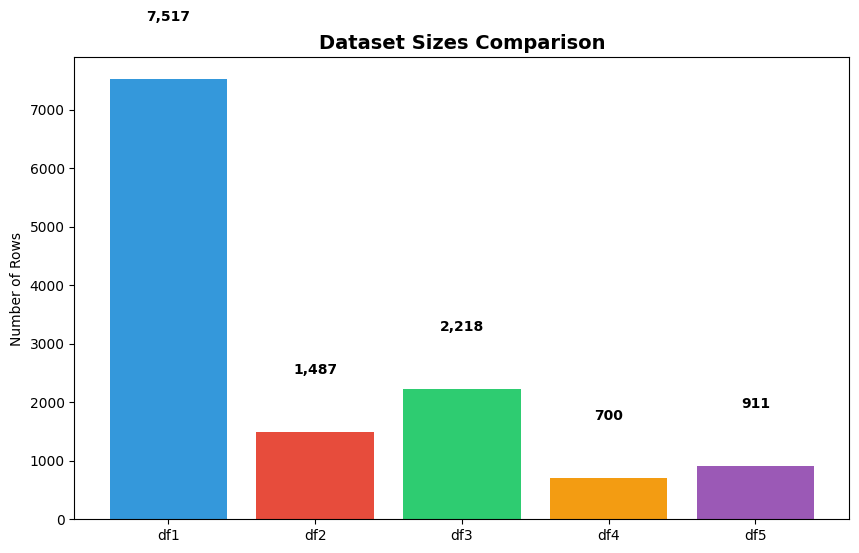

In [5]:
# data size visualization
sizes = [len(df1), len(df2), len(df3), len(df4), len(df5)]
names = ['df1', 'df2', 'df3', 'df4', 'df5']

plt.figure(figsize=(10, 6))
bars = plt.bar(names, sizes, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'])
plt.title('Dataset Sizes Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Number of Rows')

for bar, size in zip(bars, sizes):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{size:,}', ha='center', fontweight='bold')

plt.show()

**Initial EDA before labelling df5**

class distribution

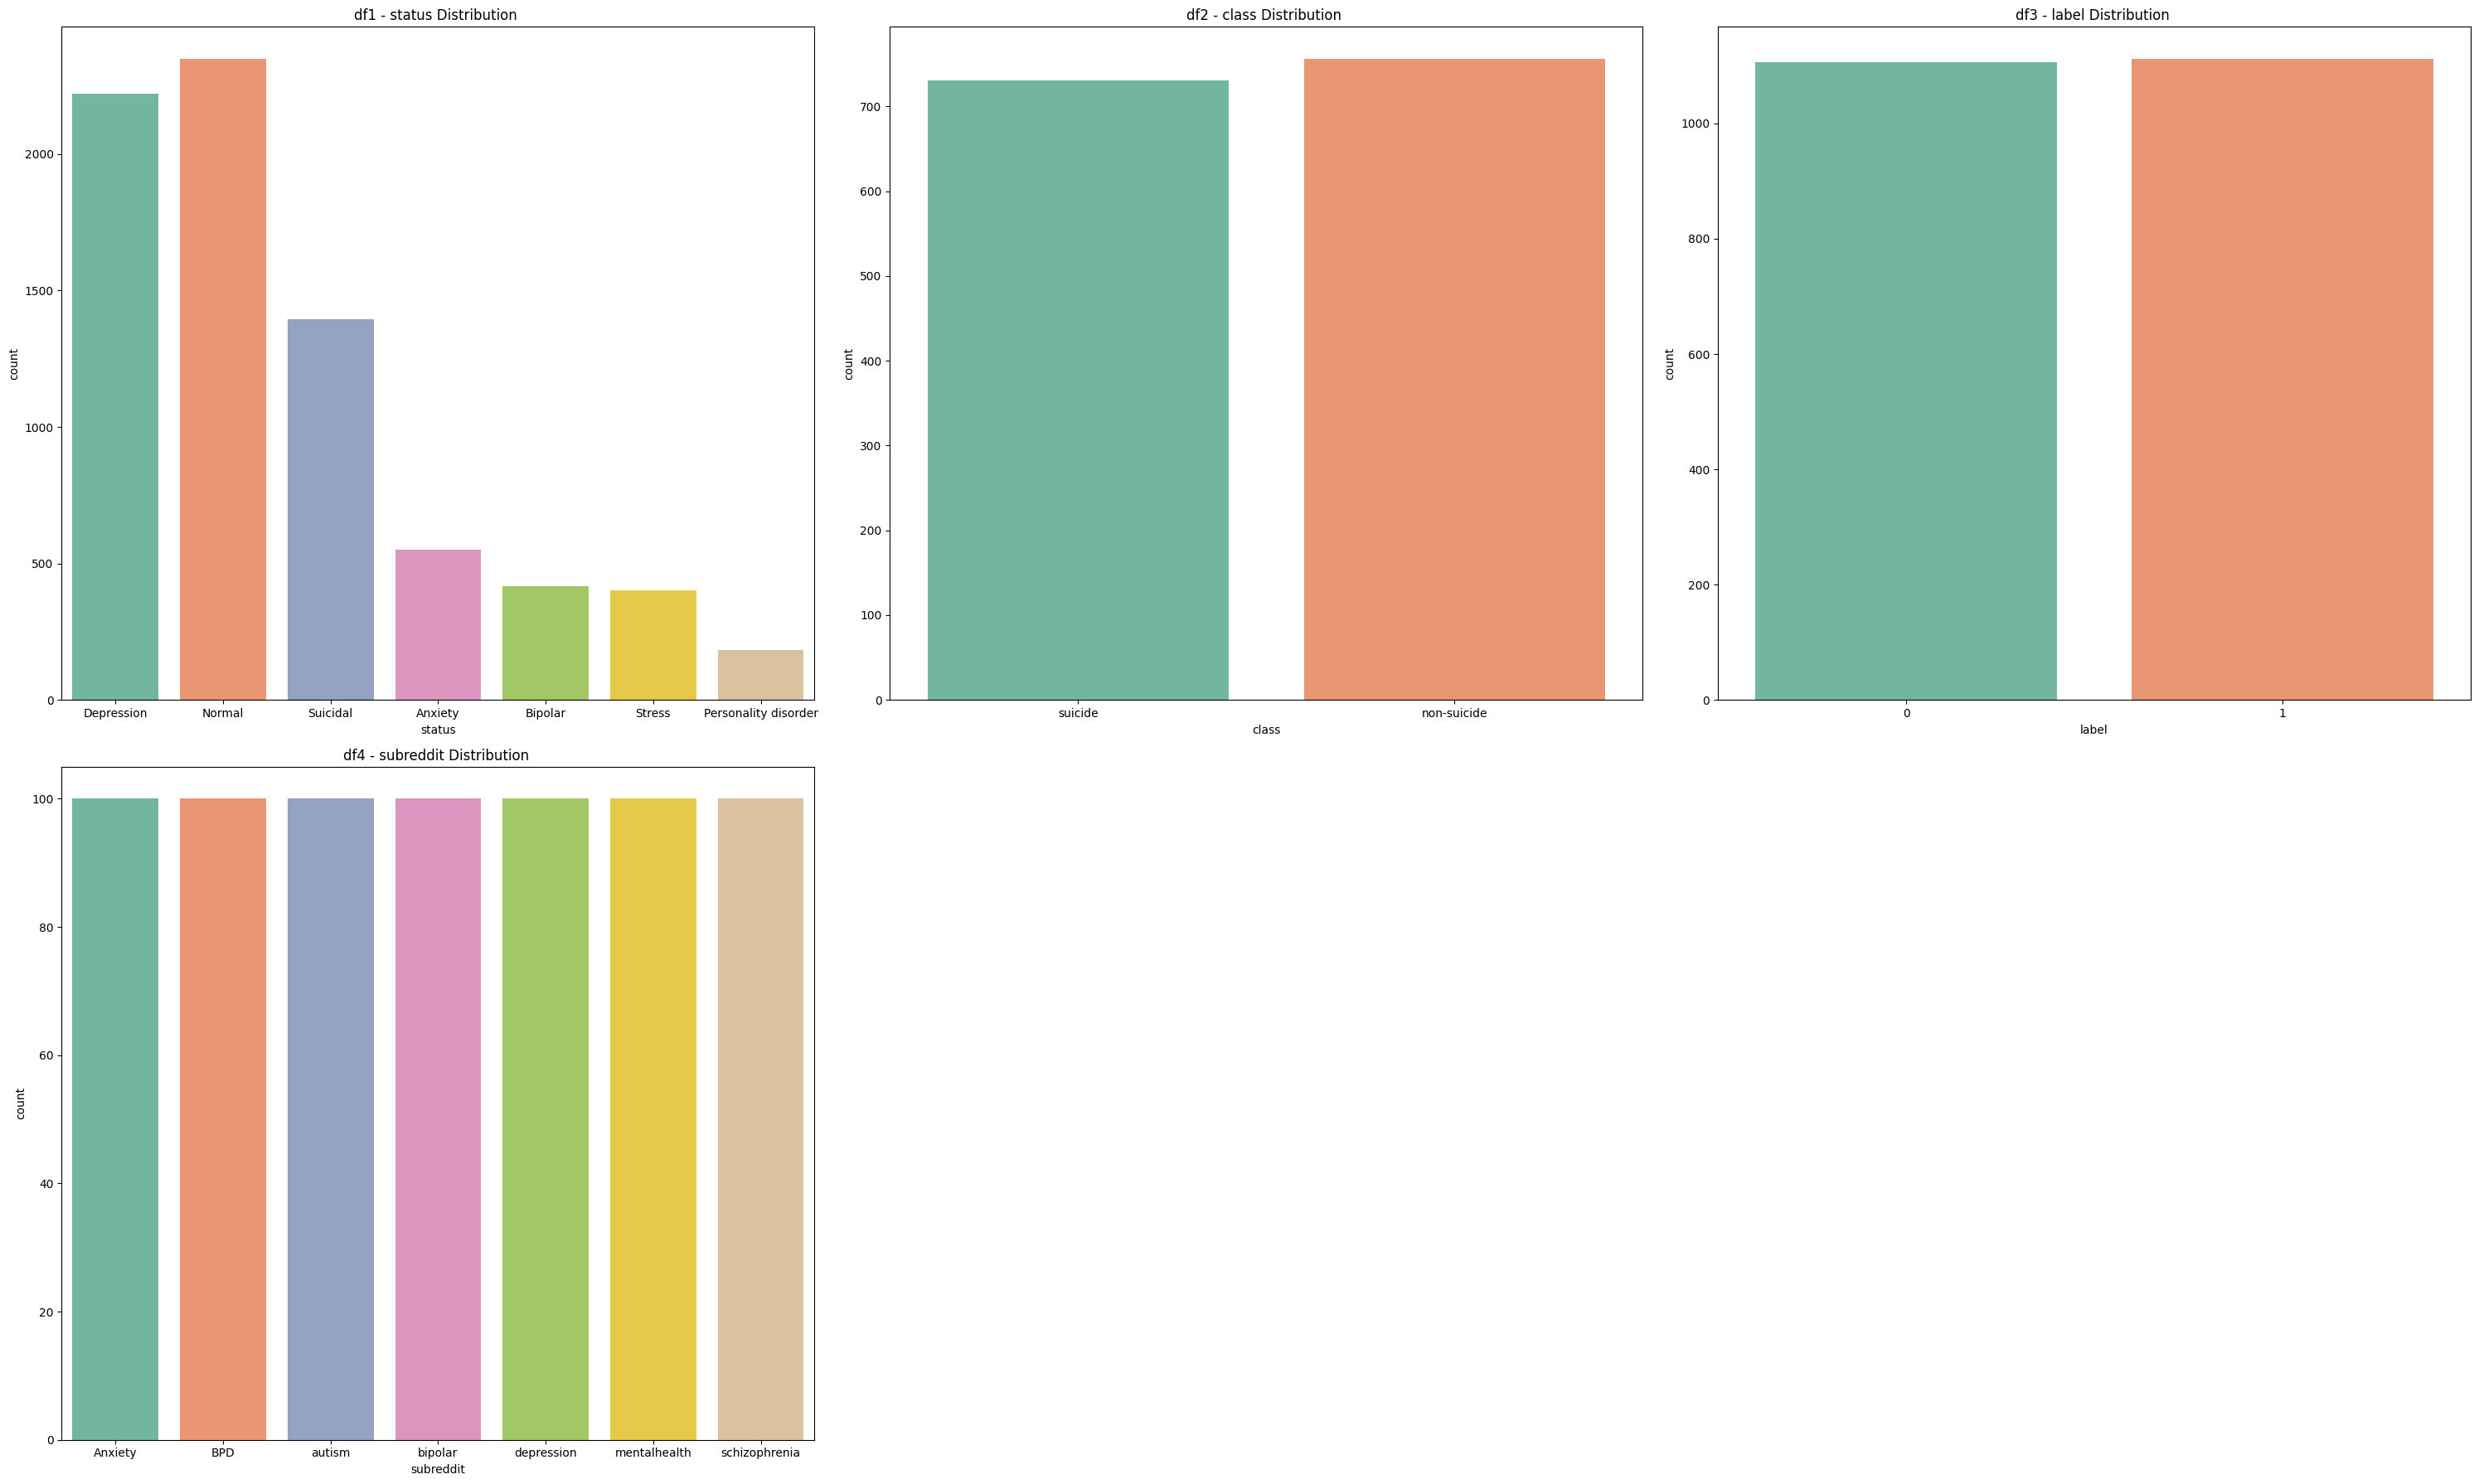

In [6]:
# class distributions

datasets = [
    (df1, 'df1', 'status'),
    (df2, 'df2', 'class'),
    (df3, 'df3', 'label'),
    (df4, 'df4', 'subreddit')
]

fig, axes = plt.subplots(2, 3, figsize=(30, 18))

axes = axes.flatten()

for ax, (df, name, target) in zip(axes, datasets):
    sns.countplot(x=target, data=df, ax=ax , palette='Set2')
    ax.set_title(f"{name} - {target} Distribution ")

for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
plt.show()


Text Length Distribution

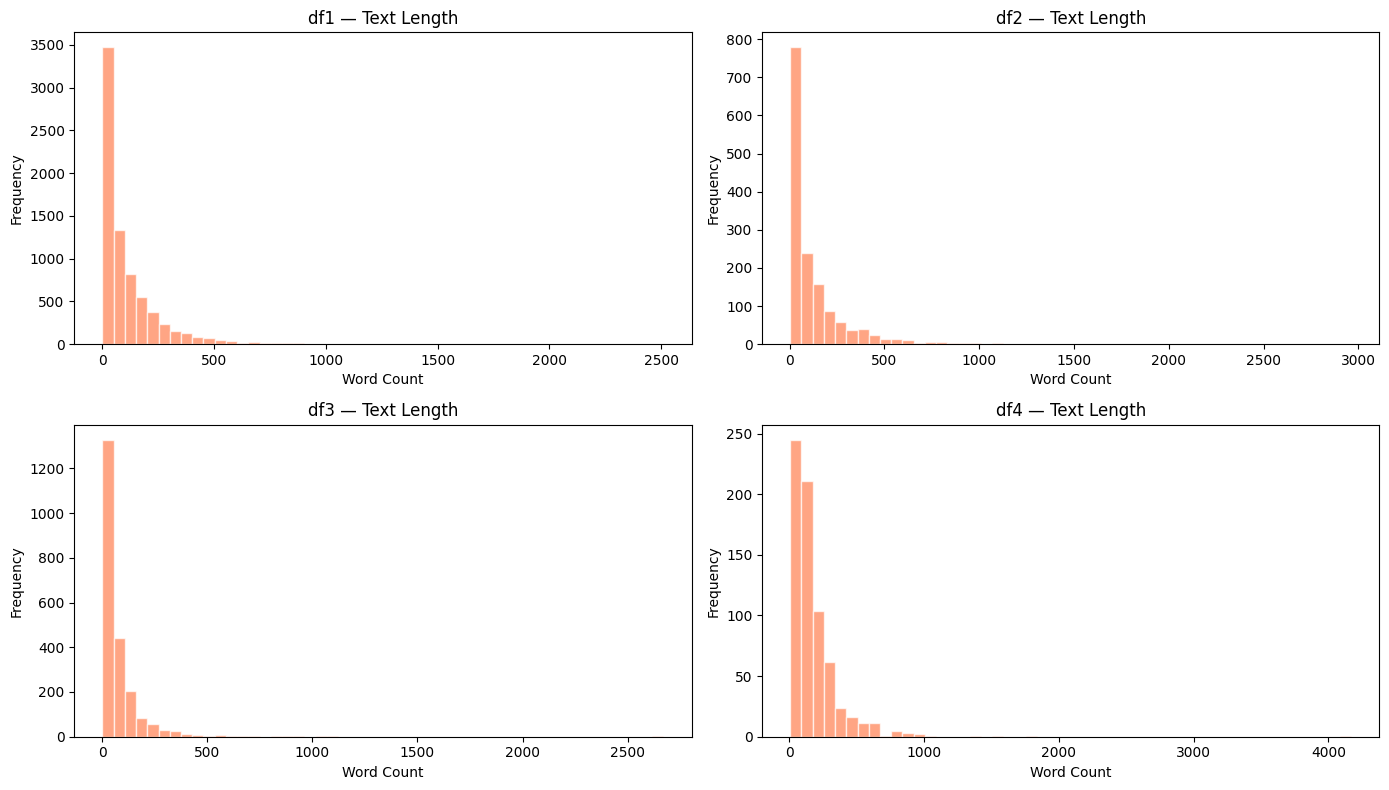

In [ ]:
#Text Length Distribution

datasets = [
    (df1, 'df1', 'statement'),
    (df2, 'df2', 'text'),
    (df3, 'df3', 'text'),
    (df4, 'df4', 'content'),
    (df5, 'df5', 'usertext')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (df, name, text_col) in zip(axes, datasets):
    if text_col in df.columns:
        word_counts = df[text_col].dropna().astype(str).str.split().str.len()

        # histogram
        ax.hist(word_counts, bins=50, color='coral', alpha=0.7, edgecolor='white')
        ax.set_title(f'{name} — Text Length')
        ax.set_xlabel('Word Count')
        ax.set_ylabel('Frequency')



plt.tight_layout()
plt.show()

Text quality of our datasets

In [8]:
#text quality
print("\n" + "="*60)
print("TEXT QUALITY CHECK")
print("="*60)

quality_metrics = []

# Regex patterns
url_pattern = r"http[s]?://\S+"
mention_pattern = r"@\w+"
html_pattern = r"<[^>]+>"
non_alpha_pattern = r"[^a-zA-Z\s]"

for df, name, text_col in datasets:

    if text_col not in df.columns:
        print(f"\n{name.upper()}: Text column '{text_col}' not found")
        continue

    texts = df[text_col].dropna().astype(str)
    total = len(df)

    # Detect issues
    url_count = texts.str.contains(url_pattern, regex=True).sum()
    mention_count = texts.str.contains(mention_pattern, regex=True).sum()
    html_count = texts.str.contains(html_pattern, regex=True).sum()
    special_count = texts.str.contains(non_alpha_pattern, regex=True).sum()
    long_count = (texts.str.len() > 1000).sum()
    avg_len = texts.str.len().mean()

    quality_metrics.append({
        'Dataset': name,
        'Total Samples': total,
        'URLs': f"{url_count} ({url_count/total*100:.1f}%)",
        'Mentions': f"{mention_count} ({mention_count/total*100:.1f}%)",
        'HTML Tags': f"{html_count} ({html_count/total*100:.1f}%)",
        'Special Chars': f"{special_count} ({special_count/total*100:.1f}%)",
        'Very Long (>1000 chars)': f"{long_count} ({long_count/total*100:.1f}%)",
        'Avg Length (chars)': f"{avg_len:.0f}"
    })


    print(f"\n{name.upper()}:")
    if url_count == 0 and mention_count == 0 and html_count == 0 and special_count == 0 and long_count == 0:
        print(" No major issues detected")
    else:
        if url_count > 0: print(f" URLs detected: {url_count}")
        if mention_count > 0: print(f" Mentions detected: {mention_count}")
        if html_count > 0: print(f" HTML tags detected: {html_count}")
        if special_count > 0: print(f" Special characters detected: {special_count}")
        if long_count > 0: print(f" Very long texts (>1000 chars): {long_count}")


quality_df = pd.DataFrame(quality_metrics)
print("\n SUMMARY TABLE:")
print(quality_df.to_string(index=False))


TEXT QUALITY CHECK

DF1:
 URLs detected: 118
 Mentions detected: 132
 HTML tags detected: 15
 Special characters detected: 6243
 Very long texts (>1000 chars): 1329

DF2:
 URLs detected: 33
 Mentions detected: 1
 Special characters detected: 1424
 Very long texts (>1000 chars): 279

DF3:
 Special characters detected: 38
 Very long texts (>1000 chars): 267

DF4:
 URLs detected: 31
 Mentions detected: 1
 Special characters detected: 696
 Very long texts (>1000 chars): 219

DF5:
 Special characters detected: 892
 Very long texts (>1000 chars): 292

 SUMMARY TABLE:
Dataset  Total Samples       URLs   Mentions HTML Tags Special Chars Very Long (>1000 chars) Avg Length (chars)
    df1           7517 118 (1.6%) 132 (1.8%) 15 (0.2%)  6243 (83.1%)            1329 (17.7%)                576
    df2           1487  33 (2.2%)   1 (0.1%)  0 (0.0%)  1424 (95.8%)             279 (18.8%)                658
    df3           2218   0 (0.0%)   0 (0.0%)  0 (0.0%)     38 (1.7%)             267 (12.0%)   

Data Statistics


 DATA TEXT STATISTICS:
Dataset  Total Samples  With Text  Missing Text  Min Words  Max Words  Mean Words  Median Words  Std Words
    df1           7517       7452            65          1       2510       112.5          59.5      160.1
    df2           1487       1487             0          3       2963       125.3          56.0      180.0
    df3           2218       2218             0          2       2670        74.4          39.0      114.3
    df4            700        700             0          6       4169       183.5         126.5      238.0
    df5            911        911             0          1       3868       191.7         123.0      260.5


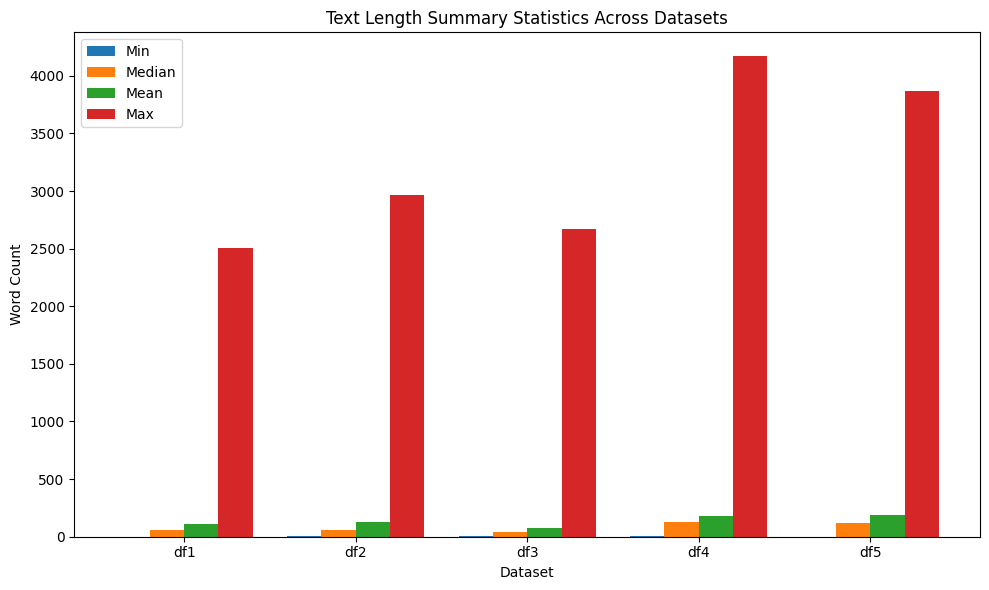

In [9]:
#Data Summary Statistics
summary_stats = []

for df, name, text_col in datasets:
    if text_col in df.columns:
        #word counts
        word_counts = df[text_col].dropna().astype(str).apply(lambda x: len(x.split()))

        summary_stats.append({
            'Dataset': name,
            'Total Samples': len(df),
            'With Text': df[text_col].notnull().sum(),
            'Missing Text': df[text_col].isnull().sum(),
            'Min Words': word_counts.min(),
            'Max Words': word_counts.max(),
            'Mean Words': round(word_counts.mean(), 1),
            'Median Words': word_counts.median(),
            'Std Words': round(word_counts.std(), 1)
        })

summary_df = pd.DataFrame(summary_stats)
print("\n DATA TEXT STATISTICS:")
print(summary_df.to_string(index=False))



stats_to_plot = summary_df[['Dataset', 'Min Words', 'Median Words', 'Mean Words', 'Max Words']]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(stats_to_plot['Dataset']))

width = 0.2

# Plot bars
ax.bar(x - 1.5*width, stats_to_plot['Min Words'], width, label='Min')
ax.bar(x - 0.5*width, stats_to_plot['Median Words'], width, label='Median')
ax.bar(x + 0.5*width, stats_to_plot['Mean Words'], width, label='Mean')
ax.bar(x + 1.5*width, stats_to_plot['Max Words'], width, label='Max')

ax.set_xticks(x)
ax.set_xticklabels(stats_to_plot['Dataset'])
ax.set_ylabel('Word Count')
ax.set_xlabel('Dataset')
ax.set_title('Text Length Summary Statistics Across Datasets')
ax.legend()
plt.tight_layout()
plt.show()

Text Length based on target labels

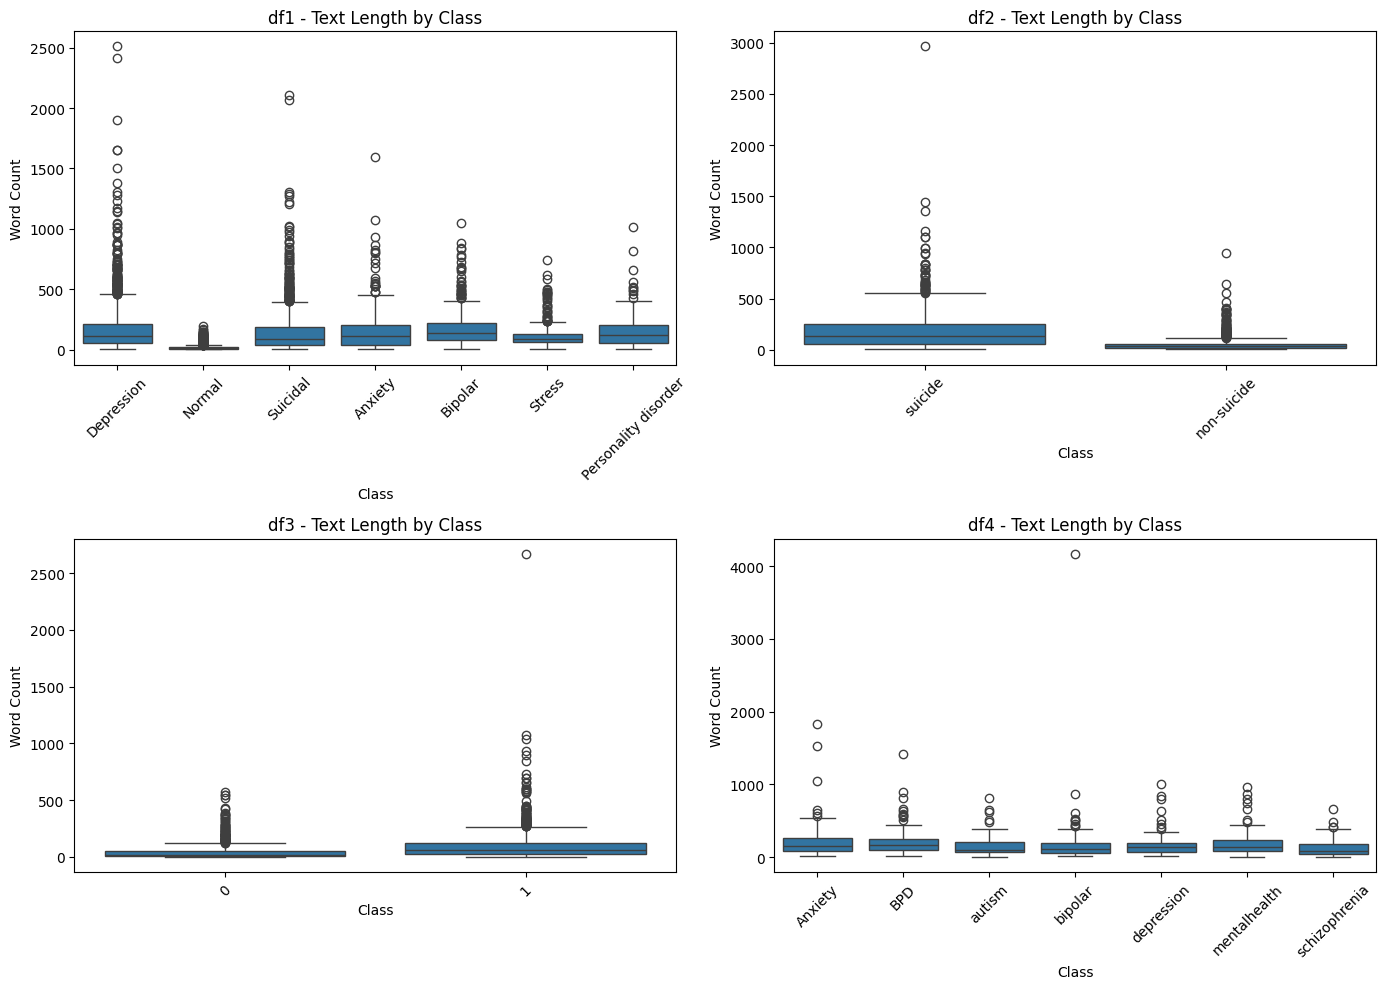

In [10]:
# Text Length by Target Class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (df, name, target, text_col) in zip(axes,
    [(df1, 'df1', 'status', 'statement'),
     (df2, 'df2', 'class', 'text'),
     (df3, 'df3', 'label', 'text'),
     (df4, 'df4', 'subreddit', 'content')]):

    if text_col in df.columns and target in df.columns:
        df_copy = df[[text_col, target]].dropna().copy()
        df_copy['word_count'] = df_copy[text_col].astype(str).str.split().str.len()

        # Box plot
        sns.boxplot(data=df_copy, x=target, y='word_count', ax=ax)
        ax.set_title(f'{name} - Text Length by Class')
        ax.set_xlabel('Class')
        ax.set_ylabel('Word Count')
        ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Word Frequency 


WORD FREQUENCY ANALYSIS (MEANINGFUL WORDS)

DF1 - Top Meaningful Words:
      Word  Count
      life   3137
      help   1537
   anxiety   1406
      work   1382
depression   1253
   friends   1197
    better   1177
      good   1154
    family    953
      hate    907
      love    892
      live    850
      hard    818
   fucking    815
      long    793


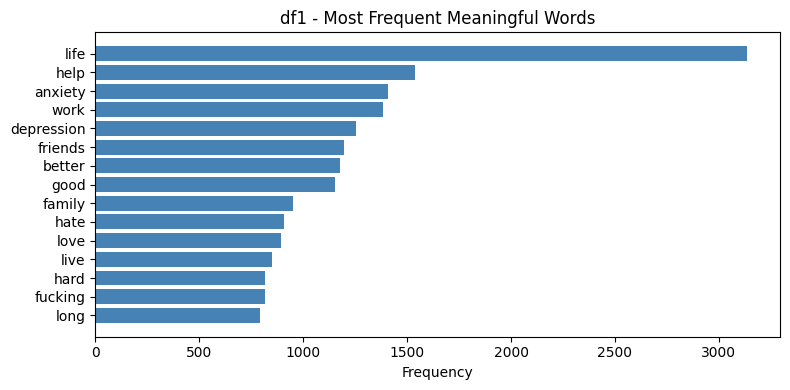


DF2 - Top Meaningful Words:
          Word  Count
          life    721
          help    363
discochocolate    341
       friends    331
          fuck    330
          good    310
        school    300
       fucking    283
        better    267
       suicide    251
          shit    249
        family    234
          live    227
          kill    223
          love    223


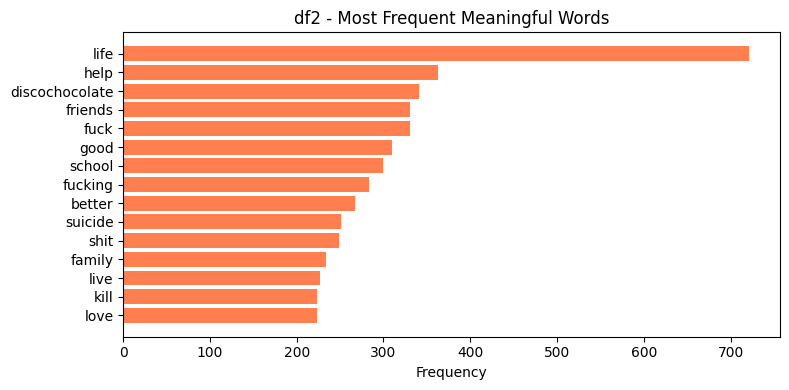


DF3 - Top Meaningful Words:
   Word  Count
   life   1330
   good    597
friends    579
   help    520
 better    431
   love    409
   live    396
fucking    395
 school    373
   work    351
 family    349
   shit    343
   hate    332
  movie    324
redflag    318


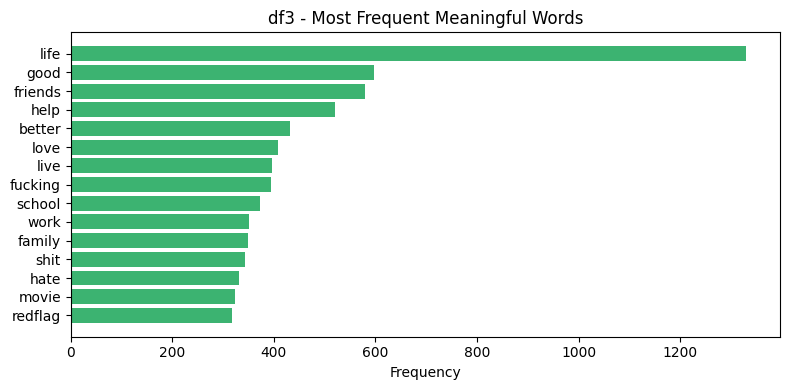


DF4 - Top Meaningful Words:
      Word  Count
      life    321
   anxiety    280
      help    238
      work    207
   friends    204
      good    179
   started    156
    better    153
    trying    147
depression    124
      felt    120
      hard    119
      love    118
    school    116
    mental    112


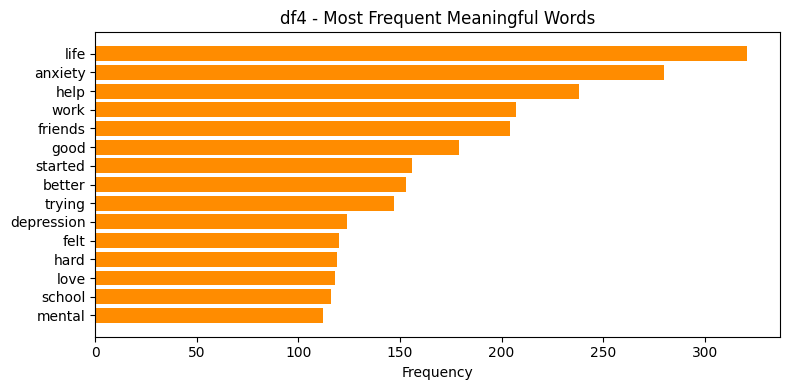


DF5 - Top Meaningful Words:
   Word  Count
   life    852
friends    404
   help    326
 family    293
 school    268
suicide    255
 better    254
fucking    250
   live    249
   good    241
   work    225
   hate    224
   kill    224
   love    214
   shit    201


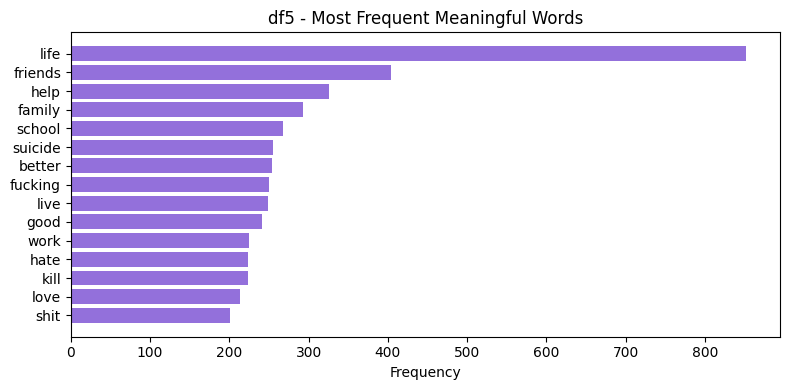

In [ ]:
# Word Frequency Analysis

print("\n" + "="*60)
print("WORD FREQUENCY ANALYSIS (MEANINGFUL WORDS)")
print("="*60)

# stopwords
stopwords = set(ENGLISH_STOP_WORDS)

# customized useless words
custom_stopwords = {
    "think","feel","feeling","really","thing","things","something","started"
    "someone","people","person","know","want","like","just","going","doesn",
    "time","day","days","way","lot","make","made","say","said","tell",
    "anymore","does","right","need","talk","years","dont","having","getting","told",
    "year","thought","doing","filler","months","doing","didn","film"
}

stopwords = stopwords.union(custom_stopwords)

dataset_colors = {
    'df1': 'steelblue',
    'df2': 'coral',
    'df3': 'mediumseagreen',
    'df4': 'darkorange',
    'df5': 'mediumpurple'
}

for df, name, text_col in datasets:

    if text_col not in df.columns:
        continue

    text = " ".join(df[text_col].dropna().astype(str))

    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    words = [w for w in words if w not in stopwords]

    common_words = Counter(words).most_common(15)

    print(f"\n{name.upper()} - Top Meaningful Words:")
    print(pd.DataFrame(common_words, columns=["Word","Count"]).to_string(index=False))

    # Plot
    w = [x[0] for x in common_words]
    c = [x[1] for x in common_words]

    plt.figure(figsize=(8,4))
    plt.barh(w[::-1], c[::-1], color=dataset_colors.get(name, 'skyblue'))
    plt.title(f"{name} - Most Frequent Meaningful Words")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()


WORD CLOUDS (MEANINGFUL WORDS) 


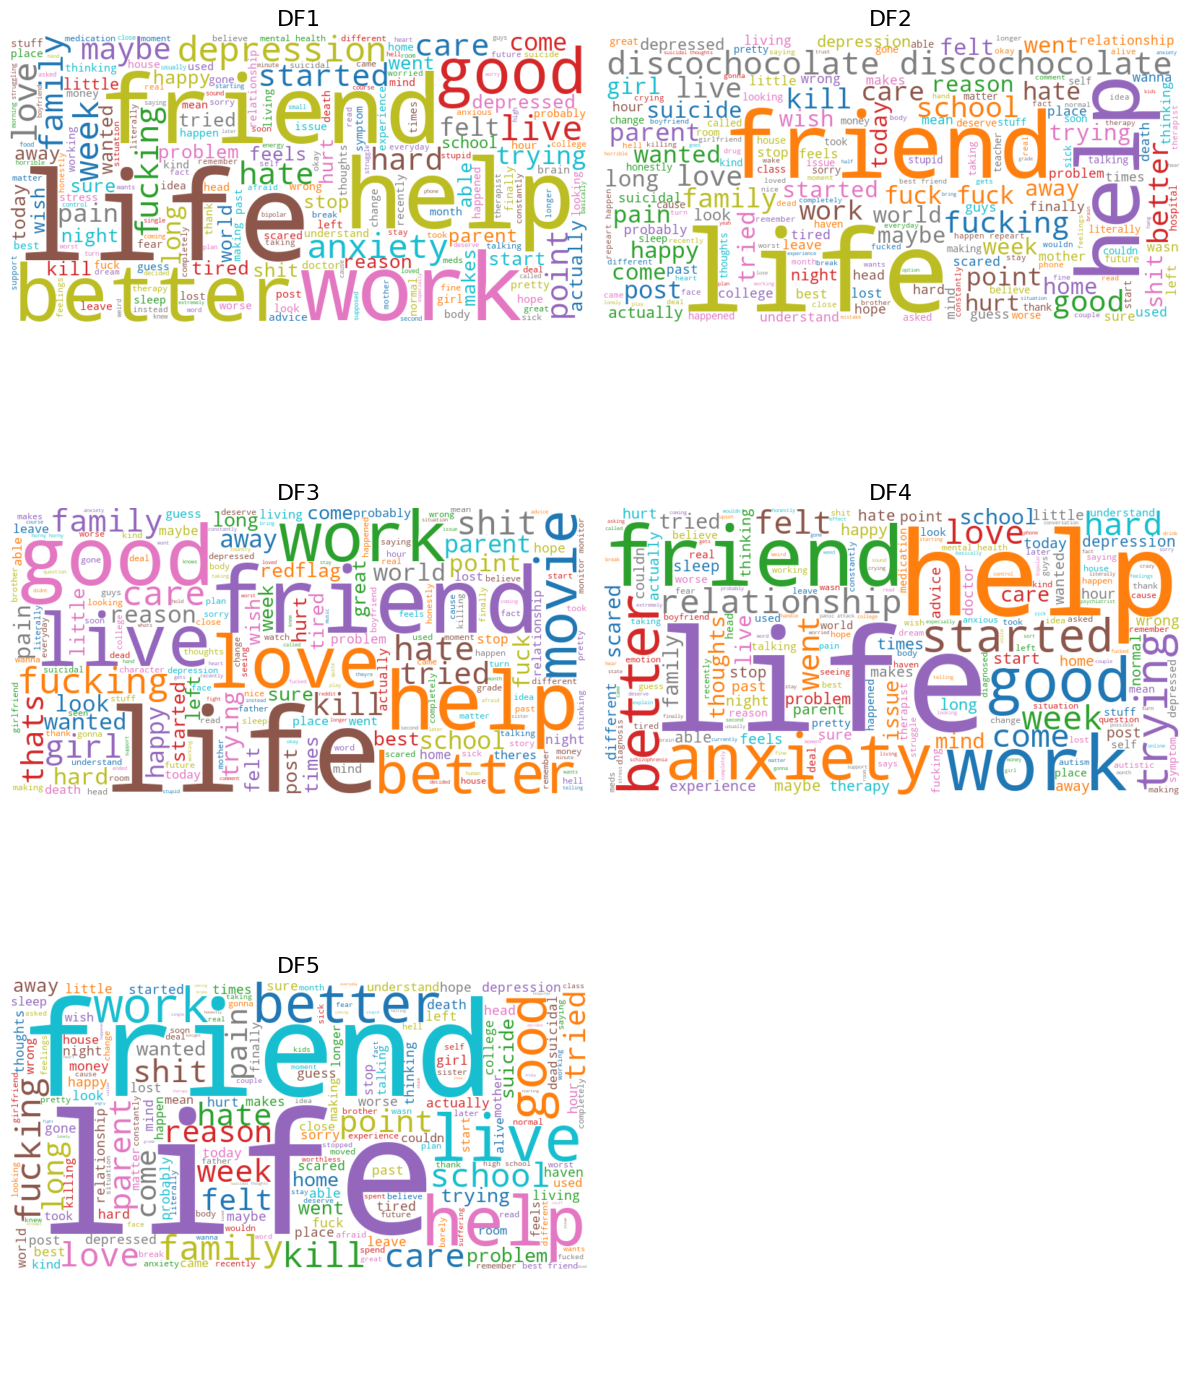

In [12]:
#WordCloud
print("\n" + "="*60)
print("WORD CLOUDS (MEANINGFUL WORDS) ")
print("="*60)

#subplots
n = len(datasets)
rows = (n + 1) // 2
cols = 2 if n > 1 else 1

fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (df, name, text_col) in zip(axes, datasets):

    if text_col not in df.columns:
        ax.axis('off')
        continue

    text = " ".join(df[text_col].dropna().astype(str))
    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    words = [w for w in words if w not in stopwords]

    if not words:
        ax.axis('off')
        continue

    # Generate WordCloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='tab10').generate(" ".join(words))

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{name.upper()}", fontsize=16)

# Hide any unused axes
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# Step : **Data Preparation**

In [13]:
# df1
df1 = df1.rename(columns={'statement': 'text', 'status': 'target'})
df1 = df1.drop(columns=['Unnamed: 0'], errors='ignore')
df1 = df1.dropna(subset=['text'])

# df2
df2 = df2.rename(columns={'class': 'target'})
df2 = df2.drop(columns=['Unnamed: 0'], errors='ignore')

# df3
df3 = df3.rename(columns={'label': 'target'})

# df4
df4 = df4.rename(columns={'content': 'text', 'subreddit': 'target'})

# df5
df5['text'] = df5['title'].fillna('') + " " + df5['usertext'].fillna('')
df5['target'] = 'unknown'
df5 = df5[['text','target']]

In [14]:
df1_clean = df1.copy()
df2_clean = df2.copy()
df3_clean = df3.copy()
df4_clean = df4.copy()
df5_clean = df5.copy()

In [15]:
#unique values of target for each dataset
dfs = [df1_clean, df2_clean, df3_clean, df4_clean, df5_clean]
for i, df in enumerate(dfs, start=1):
    print(f"df{i}  target values: {df['target'].unique()}")
    print("\n" + "*"*30 + "\n")

df1  target values: ['Depression' 'Normal' 'Suicidal' 'Anxiety' 'Bipolar' 'Stress'
 'Personality disorder']

******************************

df2  target values: ['suicide' 'non-suicide']

******************************

df3  target values: [1 0]

******************************

df4  target values: ['Anxiety' 'BPD' 'autism' 'bipolar' 'depression' 'mentalhealth'
 'schizophrenia']

******************************

df5  target values: ['unknown']

******************************



### Mapping Labels

In [16]:
#lowercase
clean_datasets = [df1_clean, df2_clean,df4_clean, df5_clean]

for df in clean_datasets:
    df['target'] = df['target'].astype(str).str.lower().str.strip()


In [17]:
label_map = {

# df1
'normal':'low_risk',
'anxiety':'moderate_risk',
'depression':'high_risk',
'suicidal':'high_risk',
'stress':'moderate_risk',
'bipolar':'moderate_risk',
'personality disorder':'moderate_risk',

# df2
'non-suicide':'unknown',
'suicide':'high_risk',

# df3
0:'low_risk',
1:'high_risk',

# df4
'anxiety':'moderate_risk',
'bpd':'moderate_risk',
'autism':'moderate_risk',
'bipolar':'moderate_risk',
'depression':'high_risk',
'mentalhealth':'moderate_risk',
'schizophrenia':'high_risk'
}

In [18]:
for df in [df1_clean, df2_clean,df3_clean ,df4_clean]:
    df['risk_level'] = df['target'].map(label_map)


### checking null values

In [19]:
#check null values
dfs = [df1_clean, df2_clean, df3_clean, df4_clean]
for i, df in enumerate(dfs, start=1):
    print(f"df{i} Nan values:\n{df.isna().sum()}")
    print("\n" + "*"*30 + "\n")

df1 Nan values:
text          0
target        0
risk_level    0
dtype: int64

******************************

df2 Nan values:
text          0
target        0
risk_level    0
dtype: int64

******************************

df3 Nan values:
text          0
target        0
risk_level    0
dtype: int64

******************************

df4 Nan values:
target        0
text          0
risk_level    0
dtype: int64

******************************



### Text Normalization (lowercase/strip spaces/normalize whitespace)

In [20]:
def normalize_text(text):
    text = str(text).lower()
    text = text.strip()
    text = " ".join(text.split())
    return text

dfs_clean = [df1_clean, df2_clean, df3_clean, df4_clean, df5_clean]

for df in dfs_clean:
    df['text'] = df['text'].apply(normalize_text)

In [21]:
# Step 1: Clean text function

def clean_text(text):

    text = re.sub(r"http\S+", "", text)      # remove URLs
    text = re.sub(r"@\w+", "", text)         # remove mentions
    text = re.sub(r"<[^>]+>", "", text)      # remove HTML tags
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove punctuation & numbers
    text = " ".join(text.split())            # remove extra spaces
    return text

for df in dfs_clean:
    df['text'] = df['text'].apply(clean_text)

In [ ]:
# -------------------------------
# Step 2: Text quality check
# -------------------------------

dfs_clean = [
    (df1_clean, 'df1_clean', 'text'),
    (df2_clean, 'df2_clean', 'text'),
    (df3_clean, 'df3_clean', 'text'),
    (df4_clean, 'df4_clean', 'text'),
    (df5_clean, 'df5_clean', 'text')
]

print("\n" + "="*60)
print("TEXT QUALITY CHECK (AFTER CLEANING)")
print("="*60)

quality_metrics = []

url_pattern = r"http[s]?://\S+"
mention_pattern = r"@\w+"
html_pattern = r"<[^>]+>"
non_alpha_pattern = r"[^a-zA-Z\s]"

for df, name, text_col in dfs_clean:

    texts = df['text'].dropna().astype(str)
    total = len(df)

    # Detect remaining issues
    url_count = texts.str.contains(url_pattern, regex=True).sum()
    mention_count = texts.str.contains(mention_pattern, regex=True).sum()
    html_count = texts.str.contains(html_pattern, regex=True).sum()
    special_count = texts.str.contains(non_alpha_pattern, regex=True).sum()
    long_count = (texts.str.len() > 1000).sum()
    avg_len = texts.str.len().mean()

    quality_metrics.append({
        'Dataset': name,
        'Total Samples': total,
        'URLs': f"{url_count} ({url_count/total*100:.1f}%)",
        'Mentions': f"{mention_count} ({mention_count/total*100:.1f}%)",
        'HTML Tags': f"{html_count} ({html_count/total*100:.1f}%)",
        'Special Chars': f"{special_count} ({special_count/total*100:.1f}%)",
        'Very Long (>1000 chars)': f"{long_count} ({long_count/total*100:.1f}%)",
        'Avg Length (chars)': f"{avg_len:.0f}"
    })

    print(f"\n{name.upper()}:")
    if url_count == 0 and mention_count == 0 and html_count == 0 and special_count == 0 and long_count == 0:
        print(" No remaining  issues detected")
    else:
        if url_count > 0: print(f" URLs detected: {url_count}")
        if mention_count > 0: print(f" Mentions detected: {mention_count}")
        if html_count > 0: print(f" HTML tags detected: {html_count}")
        if special_count > 0: print(f" Special characters detected: {special_count}")
        if long_count > 0: print(f" Very long texts (>1000 chars): {long_count}")

#Summary table
quality_df = pd.DataFrame(quality_metrics)
print("\n SUMMARY TABLE:")
print(quality_df.to_string(index=False))


TEXT QUALITY CHECK (AFTER CLEANING)

DF1_CLEAN:
 Very long texts (>1000 chars): 1269

DF2_CLEAN:
 Very long texts (>1000 chars): 270

DF3_CLEAN:
 Very long texts (>1000 chars): 264

DF4_CLEAN:
 Very long texts (>1000 chars): 210

DF5_CLEAN:
 Very long texts (>1000 chars): 291

 SUMMARY TABLE:
  Dataset  Total Samples     URLs Mentions HTML Tags Special Chars Very Long (>1000 chars) Avg Length (chars)
df1_clean           7452 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)            1269 (17.0%)                558
df2_clean           1487 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             270 (18.2%)                624
df3_clean           2218 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             264 (11.9%)                476
df4_clean            700 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             210 (30.0%)                935
df5_clean            911 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             291 (31.9%)                997


removing useless words (length<=3>)

In [23]:
#removing empty or short text(has no influence on the model)
def valid_length(text, min_words=3):
    return len(text.split()) >= min_words


dfs_clean = [df1_clean, df2_clean, df3_clean, df4_clean, df5_clean]

for i in range(len(dfs_clean)):
    dfs_clean[i] = dfs_clean[i].dropna(subset=['text'])
    dfs_clean[i] = dfs_clean[i][dfs_clean[i]['text'].apply(valid_length)]

df1_clean, df2_clean, df3_clean, df4_clean, df5_clean = dfs_clean

### Text Lemmatization

In [24]:
#Lemmatization

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    return " ".join(tokens)

for df in dfs_clean:
    df['text_lemmatized'] = df['text'].apply(lemmatize_text)

## Labelling df5/df2 using Semi-Supervision

In [25]:
#splitting our features and target
df= pd.concat([
    df1_clean,
    df2_clean[df2_clean['risk_level']=='high_risk'],
    df3_clean,
    df4_clean
], ignore_index=True)

X = df['text_lemmatized']
y = df['risk_level']

In [26]:
df.shape

(10943, 4)

In [27]:
y.value_counts()

risk_level
high_risk        5648
low_risk         3308
moderate_risk    1987
Name: count, dtype: int64

### Model 1 : Logistic Regression

since we have imbalanced data like (moderate risk very low) so we will use "class_weight" for LR in order **to modify the loss function in order to get larger weight for very low distributed class(moderate risk)**

In [28]:
#Train/Test splitting data

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

Note : we had done TF-IDF only on our training data , we didn't use our whole data in order **to avoid Data leakage**

In [29]:
#training of logistic Regression

#we will do (TF-IDF Vectorization) since our data is a text

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('LR', LogisticRegression(class_weight='balanced'))
])


In [30]:
param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'LR__C': [0.1, 1, 10],
    'LR__max_iter': [500, 1000, 2000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [31]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Best hyperparameters:", grid.best_params_)
print("Best CV macro F1-score:", grid.best_score_)

Best hyperparameters: {'LR__C': 10, 'LR__max_iter': 500, 'tfidf__max_features': 20000, 'tfidf__ngram_range': (1, 2)}
Best CV macro F1-score: 0.817576396410596


---> we will consider f1-score as our metric which a combination btw precision & recall


In [32]:
opt_pipeline = grid.best_estimator_

# Evaluate on test set
y_test_pred = opt_pipeline.predict(X_test)

print("Baseline Macro-F1:",
      f1_score(y_test, y_test_pred, average='macro'))

print("\nTest Set Classification Report:")
print(classification_report(y_test, y_test_pred))

Baseline Macro-F1: 0.8186833620765127

Test Set Classification Report:
               precision    recall  f1-score   support

    high_risk       0.89      0.86      0.88      1130
     low_risk       0.82      0.88      0.85       662
moderate_risk       0.74      0.73      0.73       397

     accuracy                           0.84      2189
    macro avg       0.82      0.82      0.82      2189
 weighted avg       0.84      0.84      0.84      2189



*Confusion Matrix of Risk Level Predictions on Test Set*

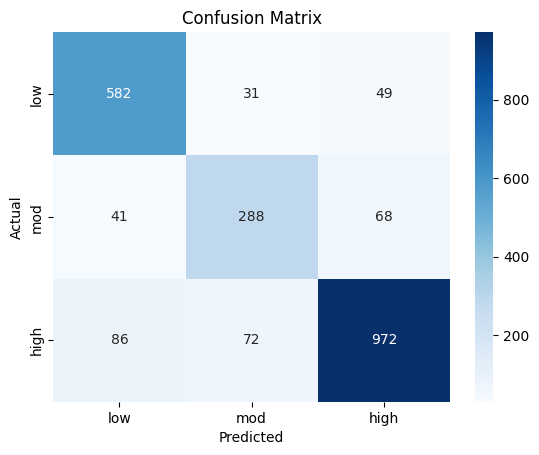

In [33]:
cm = confusion_matrix(
    y_test,
    y_test_pred ,
    labels=['low_risk','moderate_risk','high_risk']
)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['low','mod','high'],
            yticklabels=['low','mod','high'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

###  Model 2 : LightGBM

In [ ]:
smote = SMOTE(sampling_strategy={'moderate_risk': 2000}, random_state=42)

lgbm_pipeline = ImbPipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('smote', smote),  
    ('lgbm', LGBMClassifier(
        objective='multiclass',
        class_weight='balanced', 
        random_state=42
    ))
])

In [35]:
param_grid = {
    'tfidf__max_features': [5000, 10000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'lgbm__num_leaves': [31, 63],
    'lgbm__max_depth': [10, 20],
    'lgbm__learning_rate': [0.05, 0.1],
    'lgbm__n_estimators': [200, 500]
}

In [36]:
from sklearn.model_selection import RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)
print("Best hyperparameters:", random_search.best_params_)
print("Best CV Macro F1-score:", random_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025733 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 101930
[LightGBM] [Info] Number of data points in the train set: 9164, number of used features: 2576
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best hyperparameters: {'tfidf__ngram_range': (1, 1), 'tfidf__max_features': 5000, 'lgbm__num_leaves': 31, 'lgbm__n_estimators': 200, 'lgbm__max_depth': 20, 'lgbm__learning_rate': 0.05}
Best CV Macro F1-score: 0.8336949174022807


Macro-F1 on test set: 0.8352906274847203

Classification Report:
                precision    recall  f1-score   support

    high_risk       0.91      0.85      0.88      1130
     low_risk       0.81      0.90      0.85       662
moderate_risk       0.78      0.77      0.77       397

     accuracy                           0.85      2189
    macro avg       0.83      0.84      0.84      2189
 weighted avg       0.86      0.85      0.85      2189



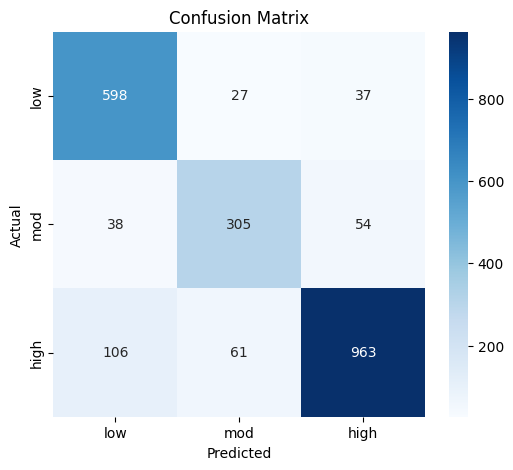

In [37]:
best_lgbm_model = random_search.best_estimator_
y_test_pred = best_lgbm_model.predict(X_test)
print("Macro-F1 on test set:", f1_score(y_test, y_test_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=['low_risk', 'moderate_risk', 'high_risk'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['low','mod','high'], yticklabels=['low','mod','high'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

STEP 1: Check confidence on training set

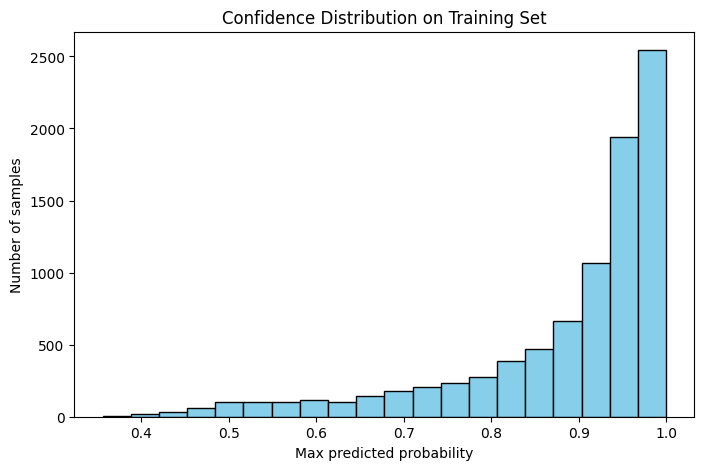

In [38]:
train_proba = best_lgbm_model.predict_proba(X_train)
max_conf = train_proba.max(axis=1)

plt.figure(figsize=(8,5))
plt.hist(max_conf, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Max predicted probability')
plt.ylabel('Number of samples')
plt.title('Confidence Distribution on Training Set')
plt.show()

>--------->Using LightBm for Labelling

with LightBm we had achieved minimum critical cases and since we are dealing with a healthcare concept , Minimization matters

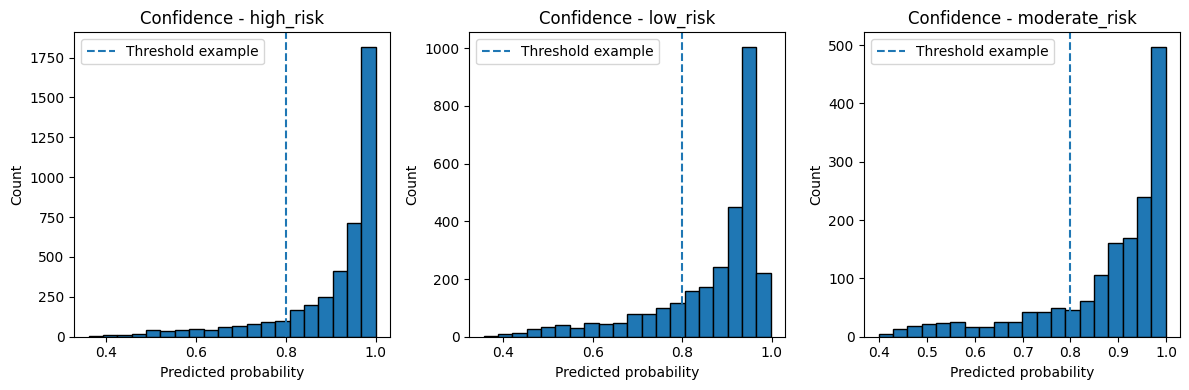

In [43]:
#  Confidence Visualization (Training Set)
train_proba = best_lgbm_model.predict_proba(X_train)
train_preds = best_lgbm_model.predict(X_train)
classes = best_lgbm_model.classes_

plt.figure(figsize=(12, 4))

for i, cls in enumerate(classes):
    plt.subplot(1, len(classes), i + 1)

    # Select samples predicted as this class
    cls_mask = train_preds == cls

    # Plot confidence distribution
    plt.hist(train_proba[cls_mask, i], bins=20, edgecolor='black')
    plt.axvline(0.8, linestyle='--', label='Threshold example')

    plt.title(f'Confidence - {cls}')
    plt.xlabel('Predicted probability')
    plt.ylabel('Count')
    plt.legend()

plt.tight_layout()
plt.show()

we had set lower threshold for high_risk in order to minimize missing critical cases

In [44]:
# Class-Specific Thresholds
class_thresholds = {
    'low_risk': 0.85,
    'moderate_risk': 0.82,
    'high_risk': 0.70   # lower to avoid missing critical cases
}

In [45]:
#Prediction with Threshold Filtering

def predict_with_class_thresholds(model, texts, thresholds):
    proba = model.predict_proba(texts)
    classes = model.classes_

    pred_final = []
    conf_final = []

    for i in range(len(texts)):
        probs = proba[i]

        # best class based on probability
        best_idx = np.argmax(probs)
        best_class = classes[best_idx]
        best_prob = probs[best_idx]

        # specific  threshold
        if best_prob >= thresholds[best_class]:
            pred_final.append(best_class)
        else:
            pred_final.append(None)  

        conf_final.append(best_prob)

    return np.array(pred_final), np.array(conf_final)




### Labeling df5

In [46]:
df5_texts = df5_clean['text_lemmatized'].fillna('').tolist()

df5_pred, df5_conf = predict_with_class_thresholds(
    best_lgbm_model,
    df5_texts,
    class_thresholds
)

df5_clean['risk_level'] = df5_pred
df5_clean['confidence'] = df5_conf


num_labeled = df5_clean['risk_level'].notna().sum()
total = len(df5_clean)

print(f"\nLabeled {num_labeled} high-confidence samples out of {total}")
print(f"Coverage: {num_labeled / total * 100:.2f}%")


Labeled 629 high-confidence samples out of 911
Coverage: 69.05%


In [47]:
print("\ndf5 distribution:")
print(df5_clean['risk_level'].value_counts(dropna=False))
print("\nConfidence stats:")
print(df5_clean['confidence'].describe())


df5 distribution:
risk_level
high_risk        599
None             282
low_risk          15
moderate_risk     15
Name: count, dtype: int64

Confidence stats:
count    911.000000
mean       0.808631
std        0.157637
min        0.378073
25%        0.685299
50%        0.860617
75%        0.943337
max        0.997935
Name: confidence, dtype: float64


### Labeling df2

In [48]:
unknown_mask = df2_clean['risk_level'] == 'unknown'
df2_unknown = df2_clean[unknown_mask].copy()

if len(df2_unknown) > 0:
    df2_texts = df2_unknown['text_lemmatized'].fillna('').tolist()
    df2_pred, df2_conf = predict_with_class_thresholds(best_lgbm_model, df2_texts, class_thresholds)

    df2_clean.loc[unknown_mask, 'risk_level'] = df2_pred
    df2_clean.loc[unknown_mask, 'confidence'] = df2_conf

    print(f"\nLabeled {np.sum(df2_pred != None)} high-confidence 'non-suicide' rows")
    print("\ndf2 final distribution:")
    print(df2_clean['risk_level'].value_counts(dropna=False))

    print("\nConfidence stats for newly labeled rows:")
    print(df2_clean.loc[unknown_mask, 'confidence'].describe())
else:
    print("No 'non-suicide' rows found to label")


Labeled 371 high-confidence 'non-suicide' rows

df2 final distribution:
risk_level
high_risk        790
None             384
low_risk         277
moderate_risk     35
Name: count, dtype: int64

Confidence stats for newly labeled rows:
count    755.000000
mean       0.772145
std        0.168402
min        0.357800
25%        0.633586
50%        0.808826
75%        0.928728
max        0.993539
Name: confidence, dtype: float64


In [49]:
# df5_clean
df5_clean = df5_clean[df5_clean['risk_level'].notna()].reset_index(drop=True)

# df2_clean
df2_clean = df2_clean[df2_clean['risk_level'].notna()].reset_index(drop=True)

#### df5/df2 shape after labelling

In [50]:
print("df5_clean shape after removing low conf:", df5_clean.shape)
print("df2_clean shape after removing  low conf :", df2_clean.shape)

df5_clean shape after removing low conf: (629, 5)
df2_clean shape after removing  low conf : (1102, 5)


In [51]:
# df5_clean
df5_clean = df5_clean.drop(columns=['confidence'])

# df2_clean
df2_clean = df2_clean.drop(columns=['confidence'])

In [ ]:
#recheck for missing & duplicated values
dfs = [df1_clean, df2_clean, df3_clean, df4_clean , df5_clean]
for i, df in enumerate(dfs, start=1):
    print(f"df{i} Nan values:\n{df.isna().sum()}")
    print(f"df{i} Duplicated values:\n{df.duplicated().sum()}")
    print("\n" + "*"*30 + "\n")

df1 Nan values:
text               0
target             0
risk_level         0
text_lemmatized    0
dtype: int64
df1 Duplicated values:
25

******************************

df2 Nan values:
text               0
target             0
risk_level         0
text_lemmatized    0
dtype: int64
df2 Duplicated values:
0

******************************

df3 Nan values:
text               0
target             0
risk_level         0
text_lemmatized    0
dtype: int64
df3 Duplicated values:
1

******************************

df4 Nan values:
target             0
text               0
risk_level         0
text_lemmatized    0
dtype: int64
df4 Duplicated values:
0

******************************

df5 Nan values:
text               0
target             0
text_lemmatized    0
risk_level         0
dtype: int64
df5 Duplicated values:
0

******************************



In [53]:
for i in range(len(dfs)):
    dfs[i].drop_duplicates(inplace=True)


In [54]:
#combine our all data

df_all = pd.concat([df1_clean, df2_clean, df3_clean, df4_clean, df5_clean], ignore_index=True)


print("Shape of merged dataset:", df_all.shape)

df_all.head()

Shape of merged dataset: (11917, 4)


,text,target,risk_level,text_lemmatized
0,just as the the title says i feel like one is ...,depression,high_risk,just a the the title say i feel like one is hy...
1,a blackened sky encroached tugging behind it m...,depression,high_risk,a blackened sky encroached tugging behind it m...
2,it gives you insomnia which in turn makes your...,depression,high_risk,it give you insomnia which in turn make your d...
3,hello all im a new submitter to this channel i...,normal,low_risk,hello all im a new submitter to this channel i...
4,thank god the cb is over for eid,normal,low_risk,thank god the cb is over for eid


Saving our full cleaned data "df_all_clean.csv"

In [55]:
df_all.to_csv("C:/Users/ASUS/Desktop/Fac/Digital_Signals/data/processed/df_all_clean.csv", index=False)

### **EDA after labelling and cleaning our Data**

#### Target  Distribution

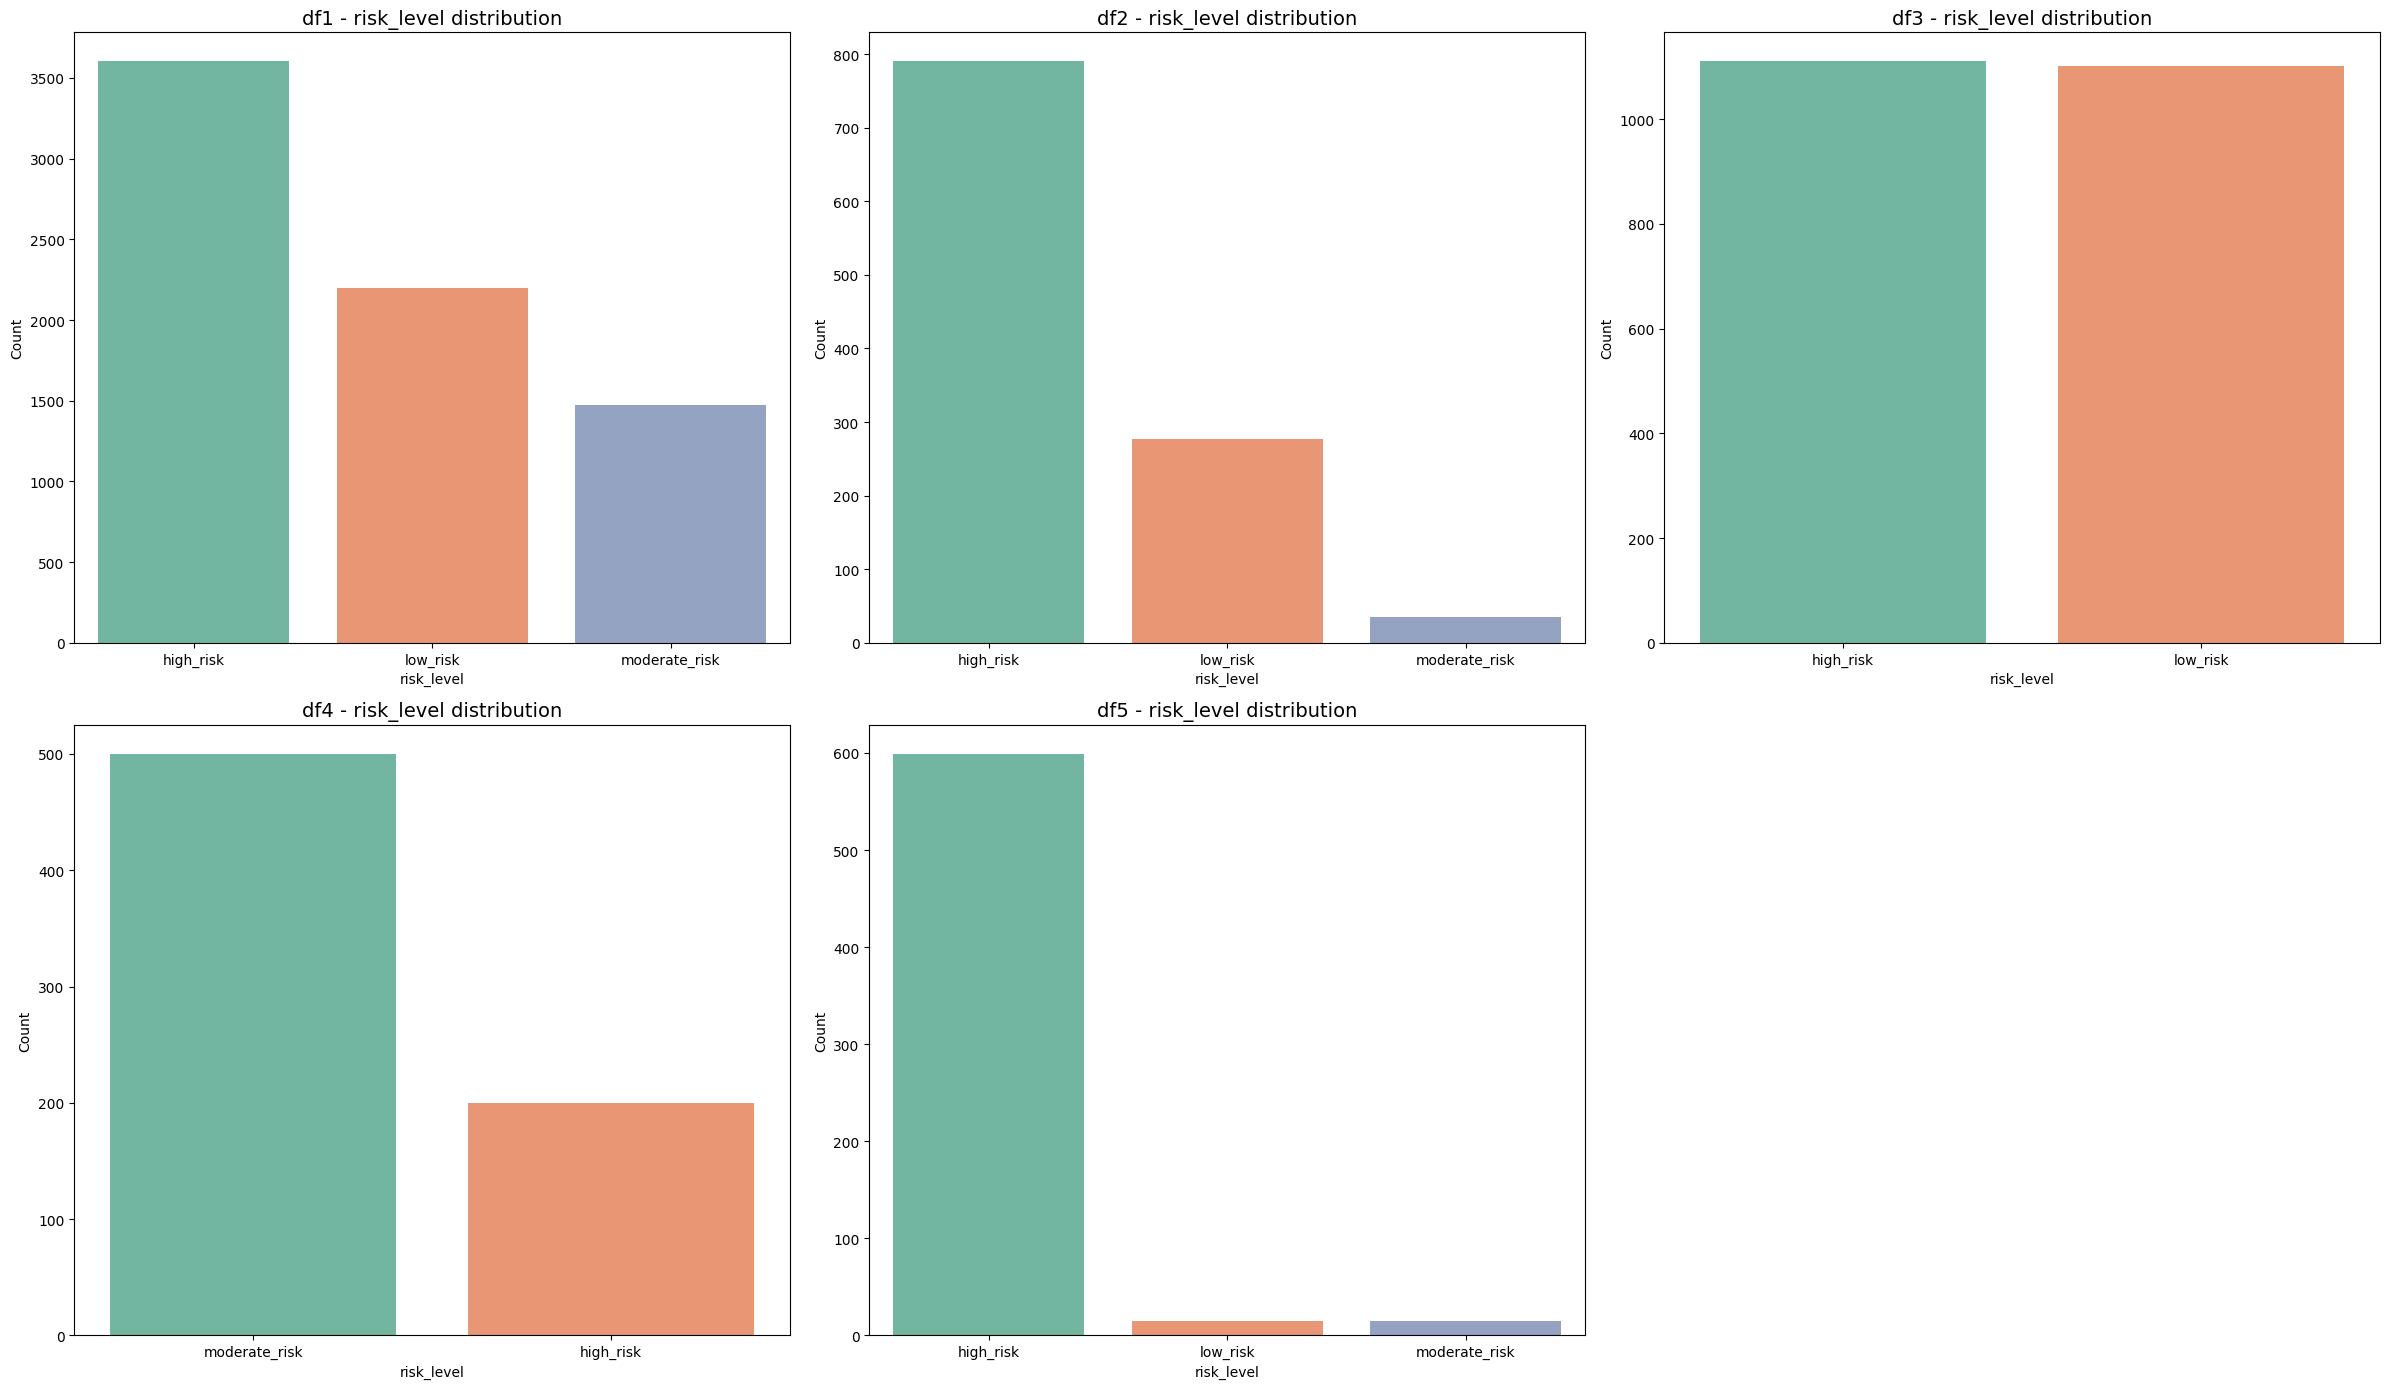

In [56]:
# class distributions
datasets = [
    ("df1", df1_clean, "risk_level"),
    ("df2", df2_clean, "risk_level"),
    ("df3", df3_clean, "risk_level"),
    ("df4", df4_clean, "risk_level"),
    ("df5", df5_clean, "risk_level")
]

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for ax, (name, df, target) in zip(axes, datasets):
    sns.countplot(data=df, x=target, ax=ax , palette='Set2')
    ax.set_title(f"{name} - {target} distribution", fontsize=14)
    ax.set_xlabel(target)
    ax.set_ylabel("Count")
# Hide unused subplot spaces
for ax in axes[len(datasets):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


#### Text Length

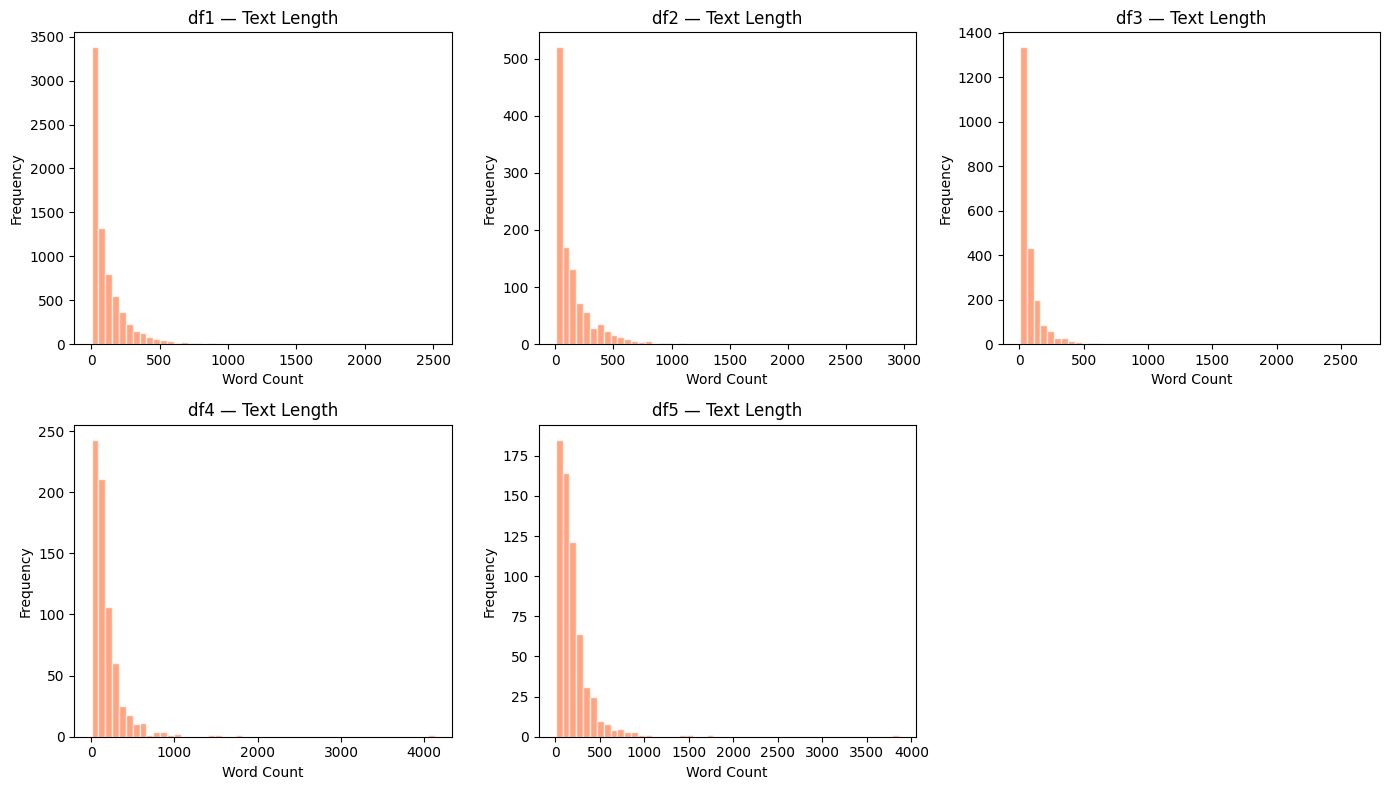

In [57]:
#Text Length Distribution

datasets = [
    (df1_clean, 'df1', 'text_lemmatized'),
    (df2_clean, 'df2', 'text_lemmatized'),
    (df3_clean, 'df3', 'text_lemmatized'),
    (df4_clean, 'df4', 'text_lemmatized'),
    (df5_clean, 'df5', 'text_lemmatized')

]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Plot text length distribution for each dataset
for ax, (df, name, text_col) in zip(axes, datasets):
    if text_col in df.columns:
        word_counts = df[text_col].dropna().astype(str).str.split().str.len()

        # histogram
        ax.hist(word_counts, bins=50, color='coral', alpha=0.7, edgecolor='white')
        ax.set_title(f'{name} — Text Length')
        ax.set_xlabel('Word Count')
        ax.set_ylabel('Frequency')


for ax in axes[len(datasets):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

#### Text Quality

In [58]:
#text quality
print("\n" + "="*60)
print("TEXT QUALITY CHECK")
print("="*60)

quality_metrics = []

# Regex patterns
url_pattern = r"http[s]?://\S+"
mention_pattern = r"@\w+"
html_pattern = r"<[^>]+>"
non_alpha_pattern = r"[^a-zA-Z\s]"

for df, name, text_col in datasets:

    if text_col not in df.columns:
        print(f"\n{name.upper()}: Text column '{text_col}' not found")
        continue

    texts = df[text_col].dropna().astype(str)
    total = len(df)

    # Detect issues
    url_count = texts.str.contains(url_pattern, regex=True).sum()
    mention_count = texts.str.contains(mention_pattern, regex=True).sum()
    html_count = texts.str.contains(html_pattern, regex=True).sum()
    special_count = texts.str.contains(non_alpha_pattern, regex=True).sum()
    long_count = (texts.str.len() > 1000).sum()
    avg_len = texts.str.len().mean()

    quality_metrics.append({
        'Dataset': name,
        'Total Samples': total,
        'URLs': f"{url_count} ({url_count/total*100:.1f}%)",
        'Mentions': f"{mention_count} ({mention_count/total*100:.1f}%)",
        'HTML Tags': f"{html_count} ({html_count/total*100:.1f}%)",
        'Special Chars': f"{special_count} ({special_count/total*100:.1f}%)",
        'Very Long (>1000 chars)': f"{long_count} ({long_count/total*100:.1f}%)",
        'Avg Length (chars)': f"{avg_len:.0f}"
    })

    # Summary print
    print(f"\n{name.upper()}:")
    if url_count == 0 and mention_count == 0 and html_count == 0 and special_count == 0 and long_count == 0:
        print(" No major issues detected")
    else:
        if url_count > 0: print(f" URLs detected: {url_count}")
        if mention_count > 0: print(f" Mentions detected: {mention_count}")
        if html_count > 0: print(f" HTML tags detected: {html_count}")
        if special_count > 0: print(f" Special characters detected: {special_count}")
        if long_count > 0: print(f" Very long texts (>1000 chars): {long_count}")

# Summary table
quality_df = pd.DataFrame(quality_metrics)
print("\n SUMMARY TABLE:")
print(quality_df.to_string(index=False))






TEXT QUALITY CHECK

DF1:
 Very long texts (>1000 chars): 1249

DF2:
 Very long texts (>1000 chars): 250

DF3:
 Very long texts (>1000 chars): 262

DF4:
 Very long texts (>1000 chars): 209

DF5:
 Very long texts (>1000 chars): 199

 SUMMARY TABLE:
Dataset  Total Samples     URLs Mentions HTML Tags Special Chars Very Long (>1000 chars) Avg Length (chars)
    df1           7275 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)            1249 (17.2%)                564
    df2           1102 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             250 (22.7%)                716
    df3           2211 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             262 (11.8%)                471
    df4            700 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             209 (29.9%)                923
    df5            629 0 (0.0%) 0 (0.0%)  0 (0.0%)      0 (0.0%)             199 (31.6%)                964


#### Data Statistics


 DATA TEXT STATISTICS:
Dataset  Total Samples  With Text  Missing Text  Min Words  Max Words  Mean Words  Median Words  Std Words
    df1           7275       7275             0          3       2511       114.4          62.0      160.7
    df2           1102       1102             0          3       2955       143.6          69.5      199.1
    df3           2211       2211             0          3       2671        74.8          40.0      114.5
    df4            700        700             0          5       4124       182.1         124.5      235.9
    df5            629        629             0          6       3858       194.7         144.0      236.6


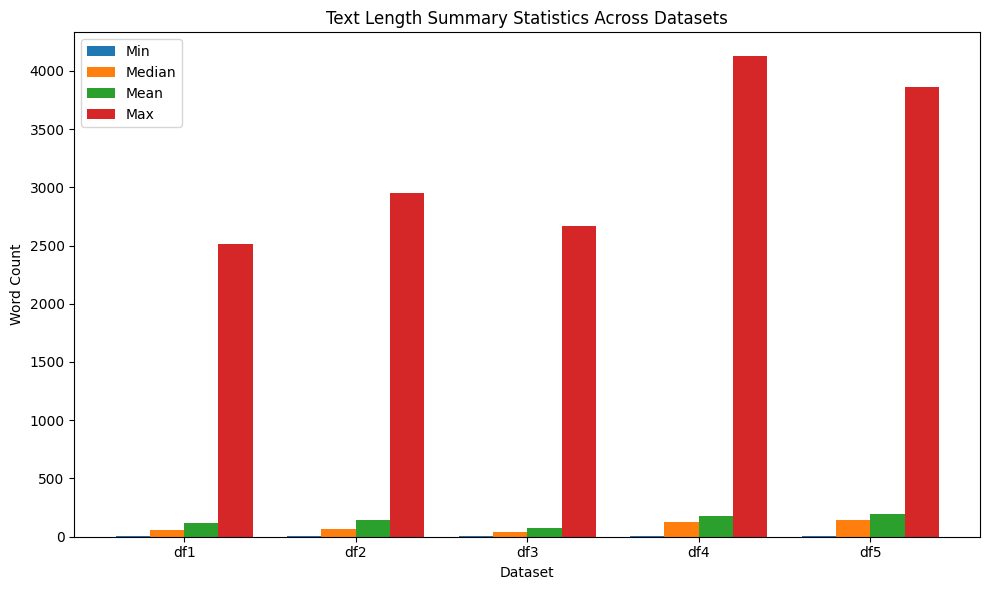

In [ ]:
summary_stats = []

for df, name, text_col in datasets:
    if text_col in df.columns:
        #word counts
        word_counts = df[text_col].dropna().astype(str).apply(lambda x: len(x.split()))

        summary_stats.append({
            'Dataset': name,
            'Total Samples': len(df),
            'With Text': df[text_col].notnull().sum(),
            'Missing Text': df[text_col].isnull().sum(),
            'Min Words': word_counts.min(),
            'Max Words': word_counts.max(),
            'Mean Words': round(word_counts.mean(), 1),
            'Median Words': word_counts.median(),
            'Std Words': round(word_counts.std(), 1)
        })

summary_df = pd.DataFrame(summary_stats)
print("\n DATA TEXT STATISTICS:")
print(summary_df.to_string(index=False))



stats_to_plot = summary_df[['Dataset', 'Min Words', 'Median Words', 'Mean Words', 'Max Words']]

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(stats_to_plot['Dataset']))

width = 0.2

ax.bar(x - 1.5*width, stats_to_plot['Min Words'], width, label='Min')
ax.bar(x - 0.5*width, stats_to_plot['Median Words'], width, label='Median')
ax.bar(x + 0.5*width, stats_to_plot['Mean Words'], width, label='Mean')
ax.bar(x + 1.5*width, stats_to_plot['Max Words'], width, label='Max')

ax.set_xticks(x)
ax.set_xticklabels(stats_to_plot['Dataset'])
ax.set_ylabel('Word Count')
ax.set_xlabel('Dataset')
ax.set_title('Text Length Summary Statistics Across Datasets')
ax.legend()
plt.tight_layout()
plt.show()

#### Text Length by Target class

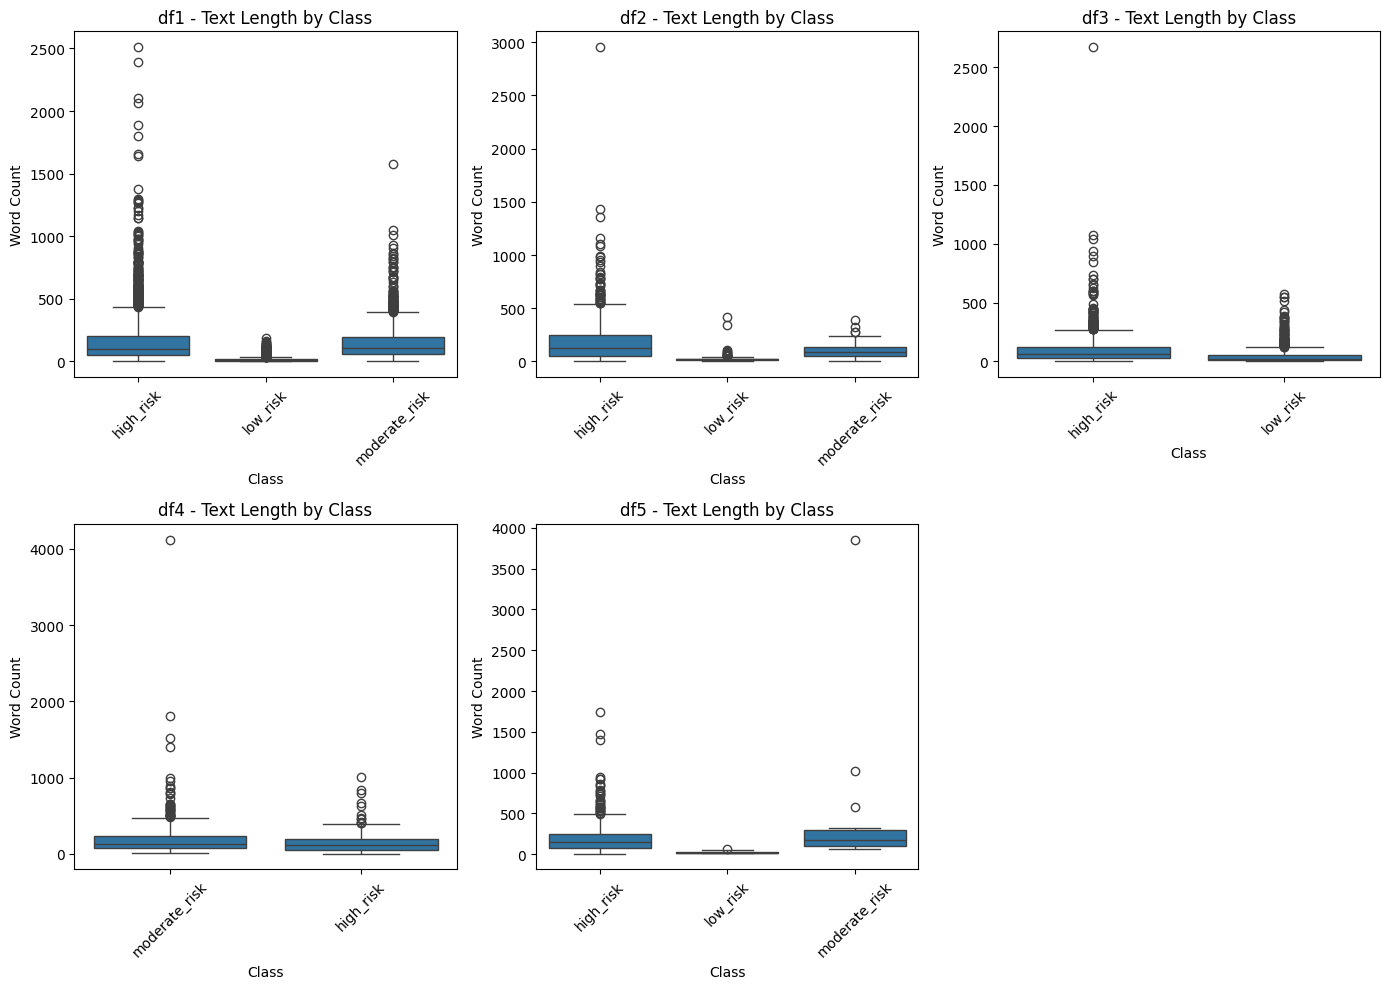

In [ ]:
# Text Length by Target Class
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (df, name, target, text_col) in zip(axes,
    [(df1_clean, 'df1', 'risk_level', 'text_lemmatized'),
     (df2_clean, 'df2', 'risk_level', 'text_lemmatized'),
     (df3_clean, 'df3', 'risk_level', 'text_lemmatized'),
     (df4_clean, 'df4', 'risk_level', 'text_lemmatized'),
     (df5_clean, 'df5', 'risk_level', 'text_lemmatized')]):

    if text_col in df.columns and target in df.columns:
        df_copy = df[[text_col, target]].dropna().copy()
        df_copy['word_count'] = df_copy[text_col].astype(str).str.split().str.len()

        sns.boxplot(data=df_copy, x=target, y='word_count', ax=ax)
        ax.set_title(f'{name} - Text Length by Class')
        ax.set_xlabel('Class')
        ax.set_ylabel('Word Count')
        ax.tick_params(axis='x', rotation=45)
for ax in axes[len(datasets):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

#### Word Frequency


WORD FREQUENCY ANALYSIS (MEANINGFUL WORDS)

DF1 - Top Meaningful Words:
      Word  Count
      life   3191
    friend   1824
      help   1615
      work   1442
   anxiety   1363
depression   1194
    better   1154
      good   1148
     month   1006
      week    953
    family    951
      hate    946
      love    936
      live    836
   fucking    812


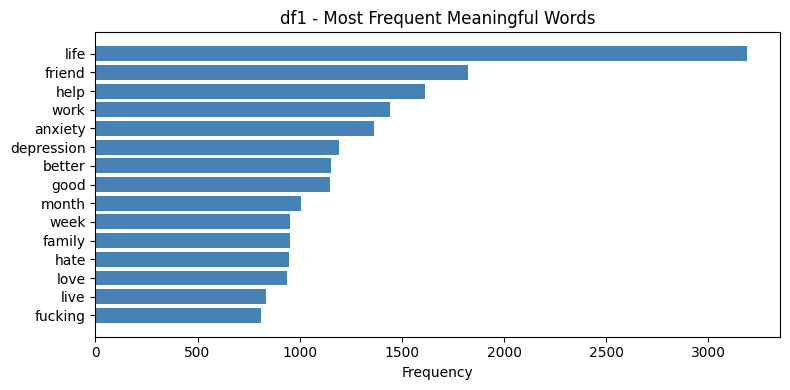


DF2 - Top Meaningful Words:
          Word  Count
          life    695
        friend    411
discochocolate    341
          help    325
          good    247
       suicide    243
        better    241
       fucking    235
          kill    234
        school    232
        family    224
          care    209
          live    208
         didnt    206
          love    202


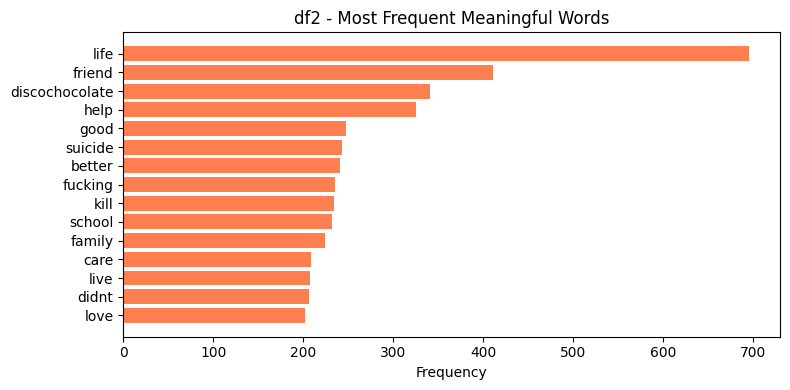


DF3 - Top Meaningful Words:
   Word  Count
   life   1416
 friend    866
   good    597
   help    542
   love    445
 better    431
  movie    404
   work    399
   live    396
fucking    395
 school    379
   hate    369
 family    364
   shit    345
   care    326


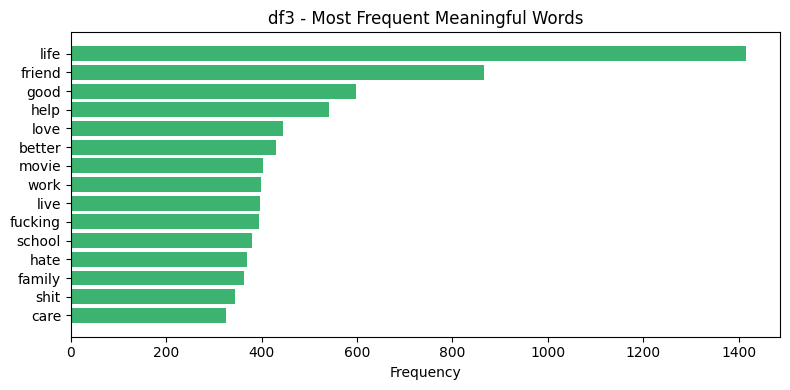


DF4 - Top Meaningful Words:
        Word  Count
        life    338
      friend    294
        help    266
     anxiety    262
        work    218
        good    179
       month    166
     started    156
      better    153
       didnt    148
      trying    147
        week    137
        tell    132
        love    131
relationship    129


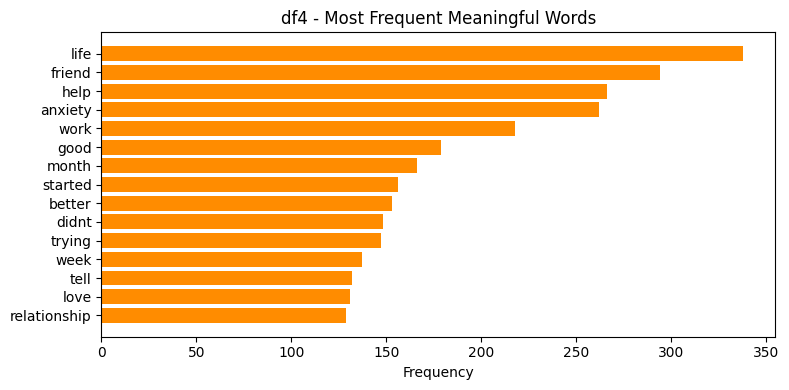


DF5 - Top Meaningful Words:
    Word  Count
    life    713
  friend    400
    help    259
 suicide    247
    kill    230
  family    208
    live    207
 fucking    204
  better    187
    hate    185
  school    177
    care    169
    shit    168
    good    167
suicidal    165


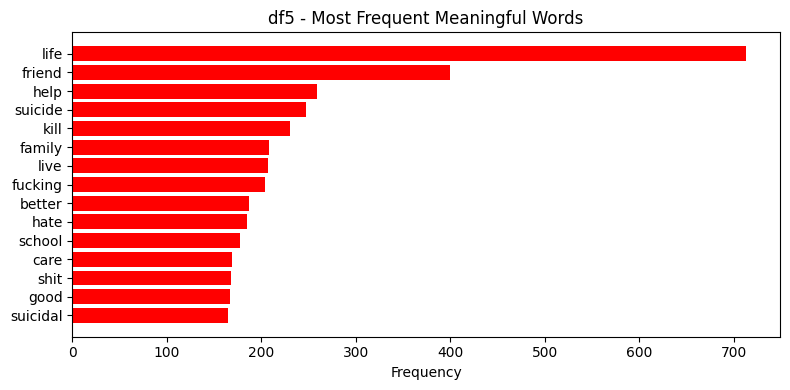

In [ ]:

print("\n" + "="*60)
print("WORD FREQUENCY ANALYSIS (MEANINGFUL WORDS)")
print("="*60)

stopwords = set(ENGLISH_STOP_WORDS)

# useless words
custom_stopwords = {
    "think","feel","feeling","really","thing","things","something",
    "someone","people","person","know","want","like","just","going",
    "time","day","days","way","lot","make","made","say","said",
    "anymore","does","right","need","talk","years","dont","having","getting","told",
    "year","thought","doing","filler","months","doing","didn","film"
}

stopwords = stopwords.union(custom_stopwords)

dataset_colors = {
    'df1': 'steelblue',
    'df2': 'coral',
    'df3': 'mediumseagreen',
    'df4': 'darkorange',
    'df5': 'red'

}

for df, name, text_col in datasets:

    if text_col not in df.columns:
        continue

    text = " ".join(df[text_col].dropna().astype(str))

    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    words = [w for w in words if w not in stopwords]

    common_words = Counter(words).most_common(15)

    print(f"\n{name.upper()} - Top Meaningful Words:")
    print(pd.DataFrame(common_words, columns=["Word","Count"]).to_string(index=False))

    # Plot
    w = [x[0] for x in common_words]
    c = [x[1] for x in common_words]

    plt.figure(figsize=(8,4))
    plt.barh(w[::-1], c[::-1], color=dataset_colors.get(name, 'skyblue'))
    plt.title(f"{name} - Most Frequent Meaningful Words")
    plt.xlabel("Frequency")
    plt.tight_layout()
    plt.show()








WordClouds


WORD CLOUDS (MEANINGFUL WORDS) 


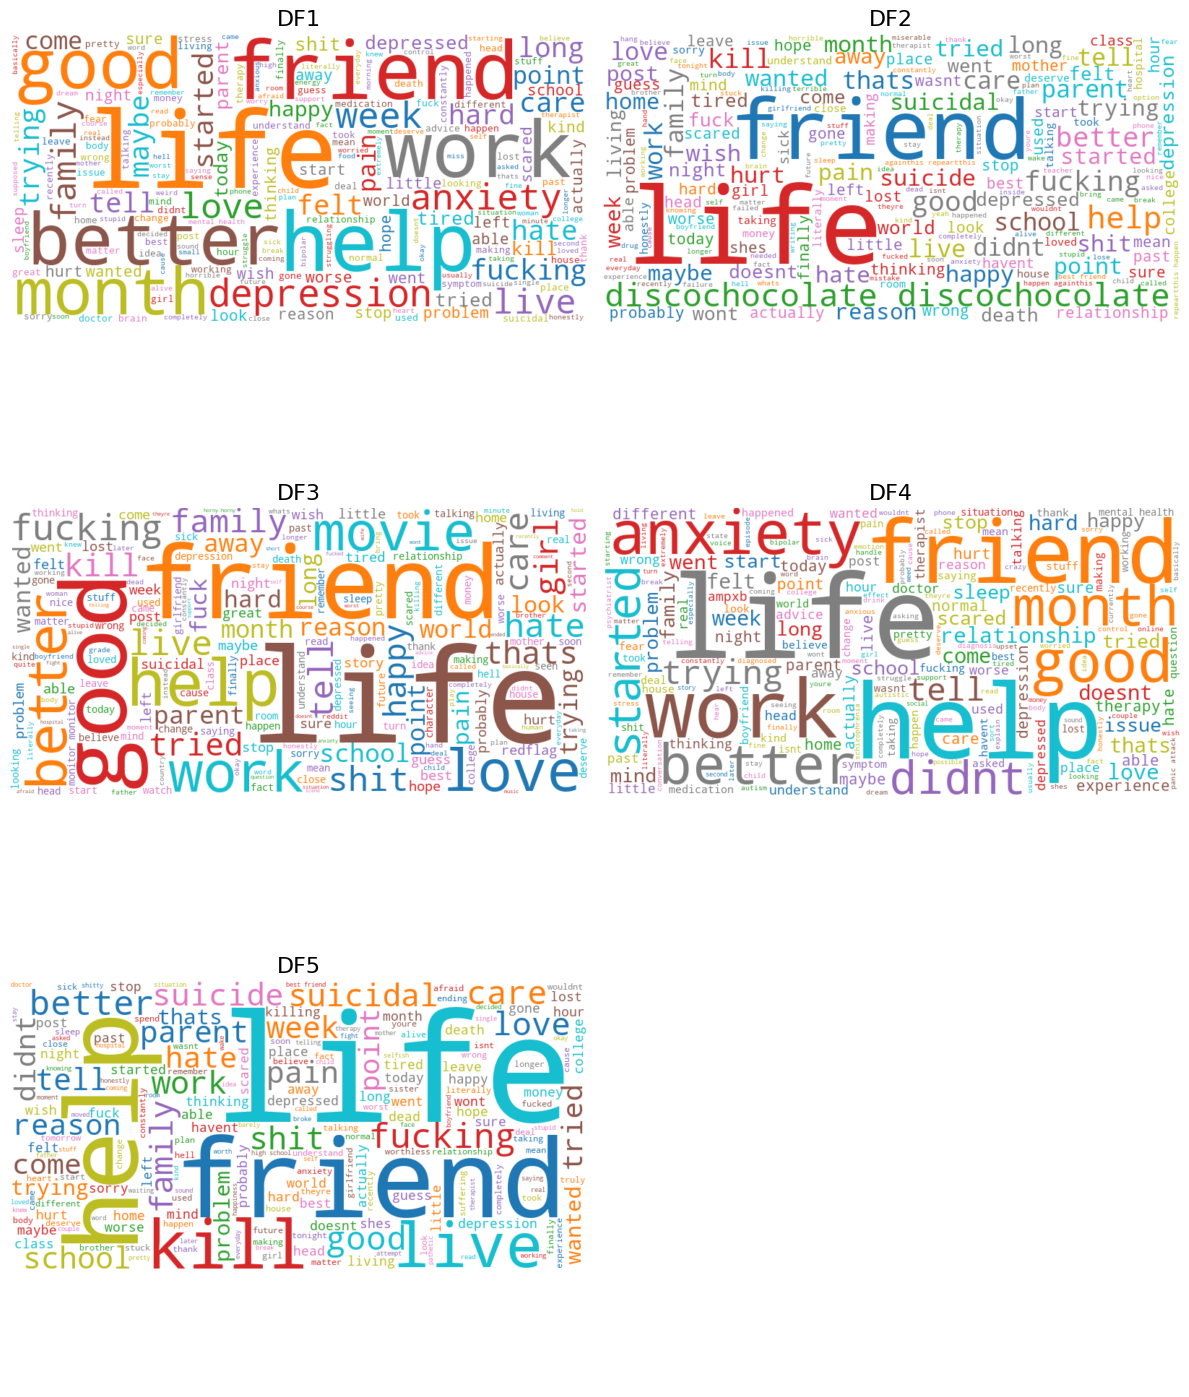

In [62]:
#WordCloud
print("\n" + "="*60)
print("WORD CLOUDS (MEANINGFUL WORDS) ")
print("="*60)

#subplots
n = len(datasets)
rows = (n + 1) // 2
cols = 2 if n > 1 else 1

fig, axes = plt.subplots(rows, cols, figsize=(12, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, (df, name, text_col) in zip(axes, datasets):

    if text_col not in df.columns:
        ax.axis('off')
        continue

    text = " ".join(df[text_col].dropna().astype(str))
    words = re.findall(r'\b[a-zA-Z]{4,}\b', text.lower())
    words = [w for w in words if w not in stopwords]

    if not words:
        ax.axis('off')
        continue

    # Generate WordCloud
    wordcloud = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='tab10').generate(" ".join(words))

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"{name.upper()}", fontsize=16)

# Hide any unused axes
for ax in axes[len(datasets):]:
    ax.axis('off')

plt.tight_layout()
plt.show()